# MHD Equilibria

## Overview

In Struphy, an **MHD equilibrium** is a background configuration that describes the magnetic field $\mathbf{B}(x, y, z)$, current density $\mathbf{J}(x, y, z)$, and plasma properties (density, pressure) in a state of force balance. These equilibria serve as the foundation for studying plasma dynamics, perturbations, and wave propagation in Struphy models.

A **domain** (or mapping) is how Struphy maps from a logical unit cube $\hat{\Omega} = (0,1)^3$ to a physical domain $\Omega \subset \mathbb{R}^3$. This enables us to work with complex geometries (cylinders, tori, tokamaks) while leveraging efficient numerical methods on the regular reference cube.

Different equilibrium classes handle this mapping relationship differently:

### Cartesian Equilibria (User Configures Domain)

`CartesianMHDequilibrium` subclasses require the developer to specify equilibrium variables in **Cartesian coordinates** $\mathbf{B}(x, y, z)$ and $\mathbf{J}(x, y, z)$. This approach is flexible—the same equilibrium can work with any domain. **You, the user, must assign a domain** after instantiating the equilibrium.

Examples: `ScrewPinch`, `AdhocTorus`, `EQDSKequilibrium`

### Logical Equilibria (Equilibrium Provides Domain)

`LogicalMHDequilibrium` subclasses provide equilibrium variables in **logical coordinates** $\hat{\mathbf{B}}^i(\eta_1, \eta_2, \eta_3)$ along with their **built-in mapping** to Cartesian coordinates. Since the mapping is part of the equilibrium definition, **you cannot change the domain**—it is fixed.

Examples: `GVECequilibrium`, `DESCequilibrium`

### In This Tutorial

We'll explore both types and see how to work with them:


In [1]:
import numpy as np

from struphy import equils
from struphy import domains

## Example 1: ScrewPinch (Cartesian Equilibrium)

**ScrewPinch** is an analytic `CartesianMHDequilibrium` describing a cylindrical plasma column with a twisted magnetic field. The equilibrium is defined in Cartesian coordinates and can be used with any cylindrical domain.

**Notice:** We instantiate the equilibrium, then assign a `HollowCylinder` domain to it. This tells Struphy how to map the logical cube to a hollow cylinder in physical space.

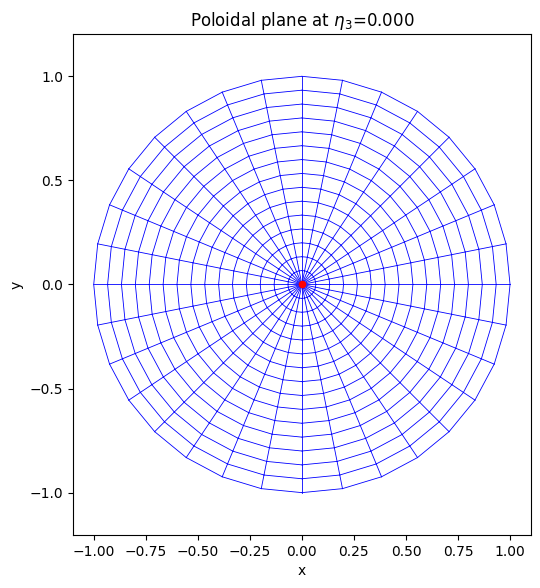

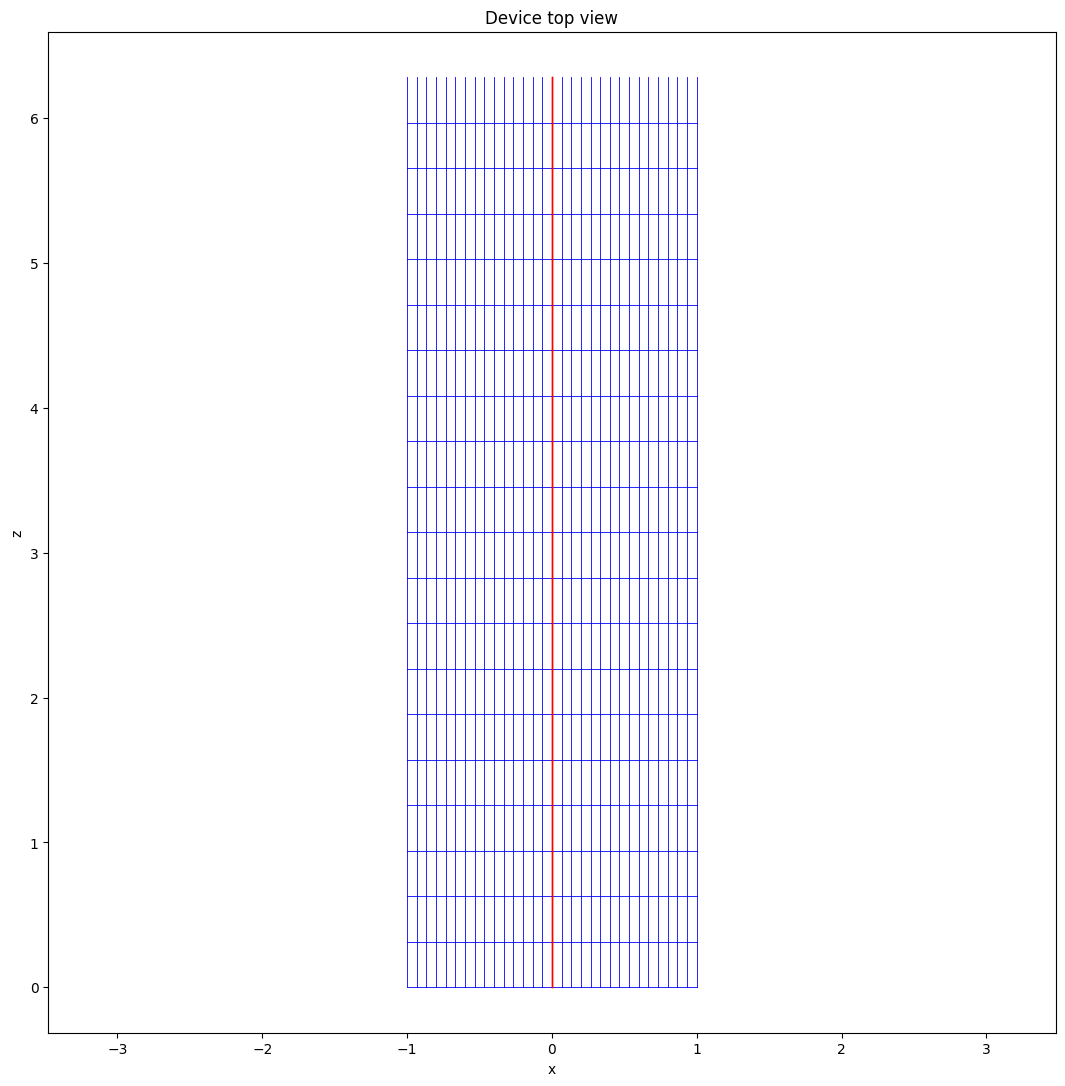

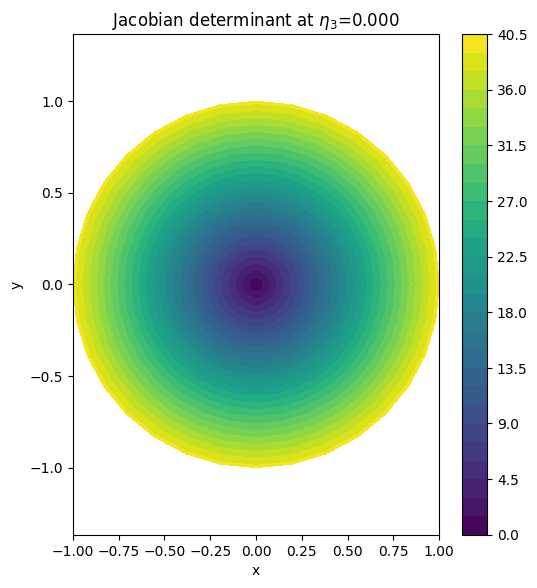

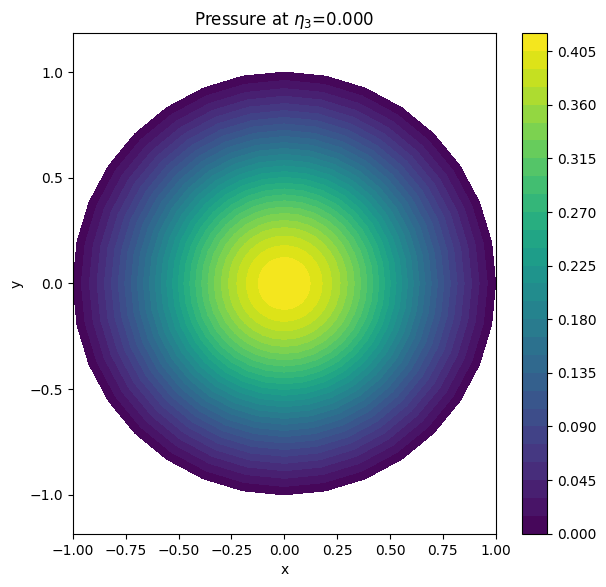

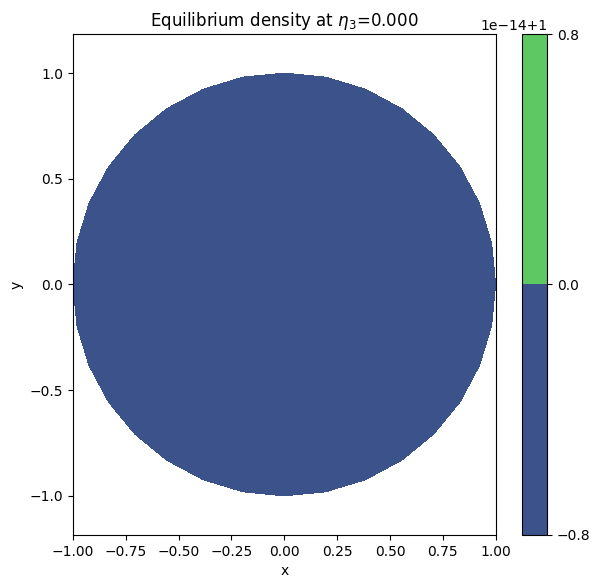

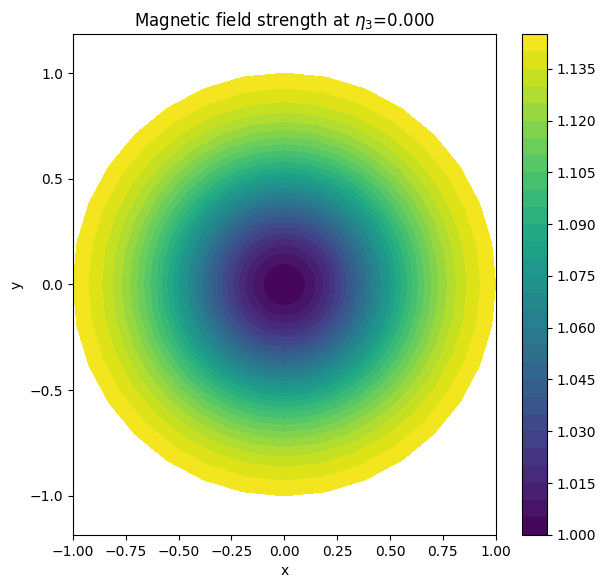

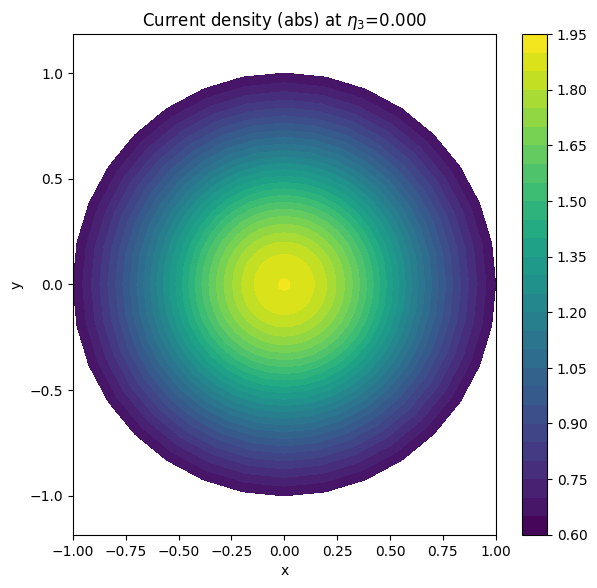

In [2]:
mhd_equil = equils.ScrewPinch(R0=1.0)
mhd_equil.domain = domains.HollowCylinder(a1=1e-8, a2=1, Lz=2 * np.pi)
mhd_equil.show()

## Example 2: AdhocTorus (Cartesian Equilibrium)

**AdhocTorus** is another `CartesianMHDequilibrium`, this time describing an analytic toroidal geometry. Like ScrewPinch, it is defined in Cartesian coordinates and requires you to assign a domain.

**Notice:** Here we use a `HollowTorus` domain, which maps the logical cube to a toroidal shape suitable for this equilibrium.

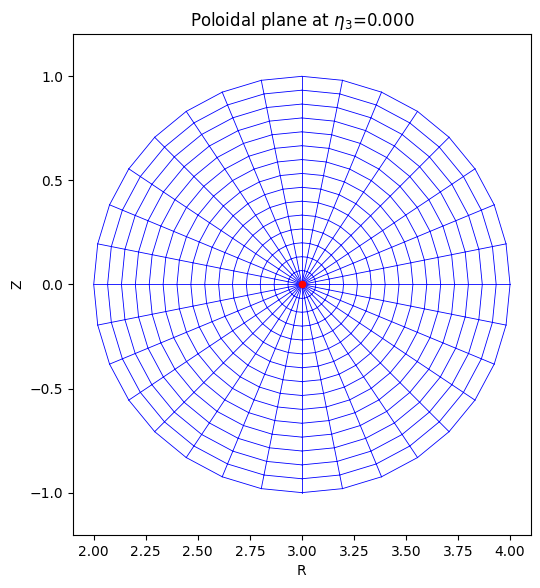

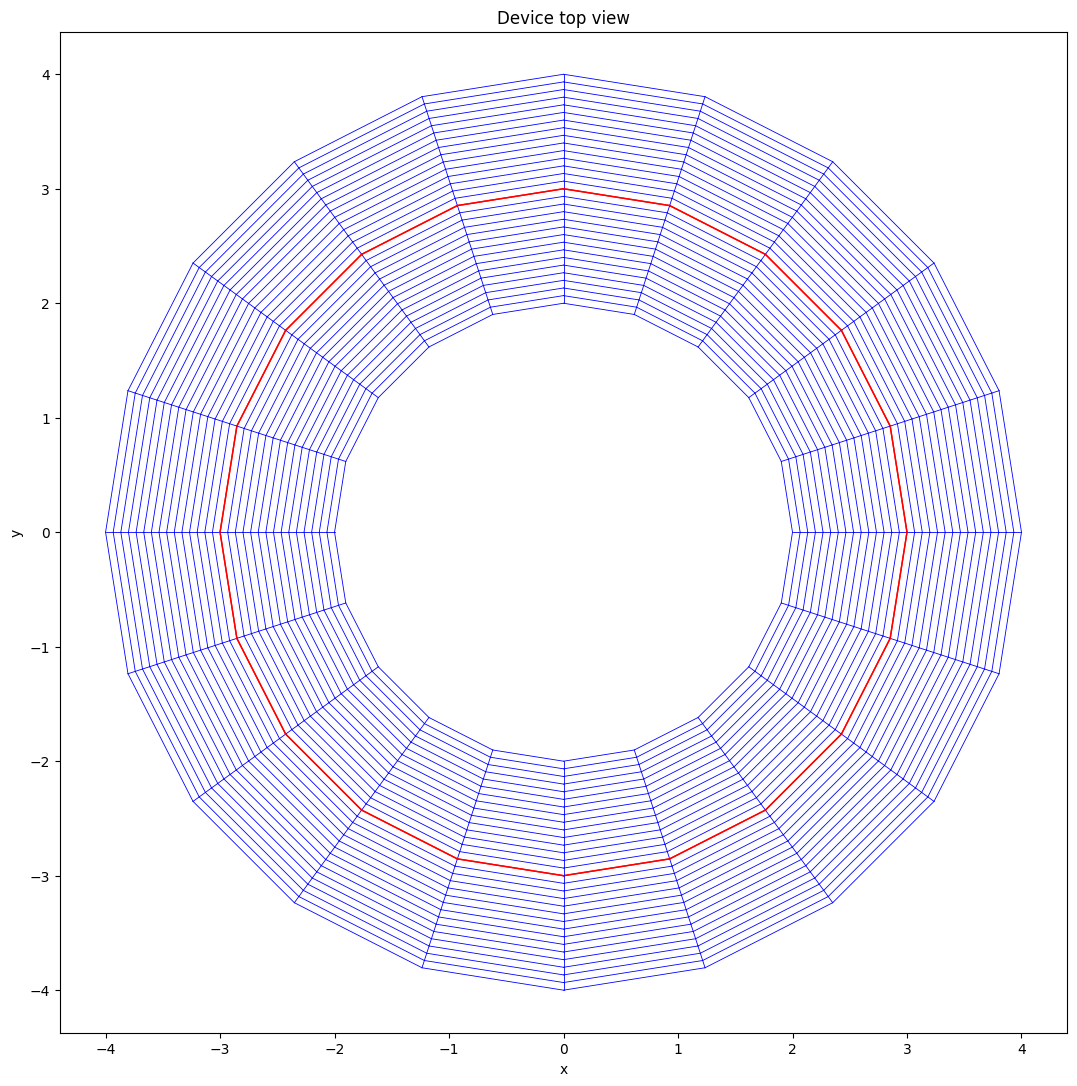

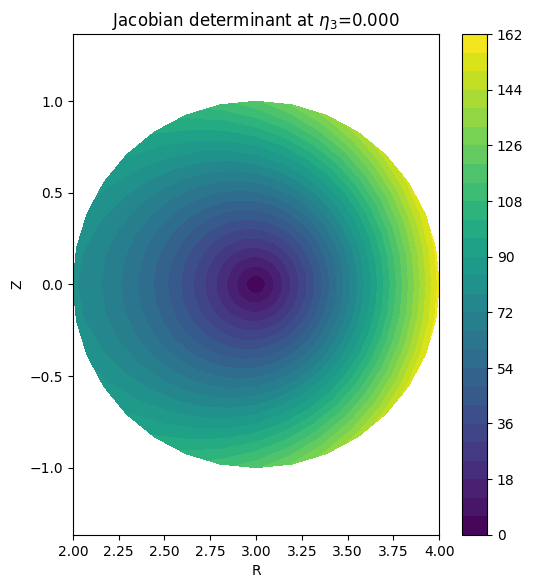

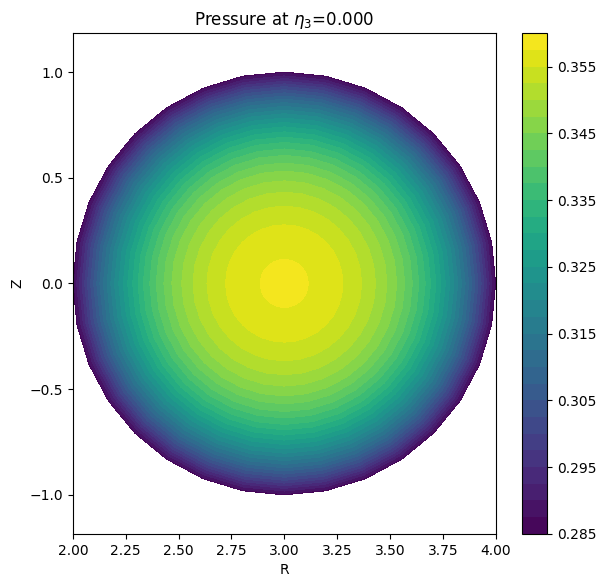

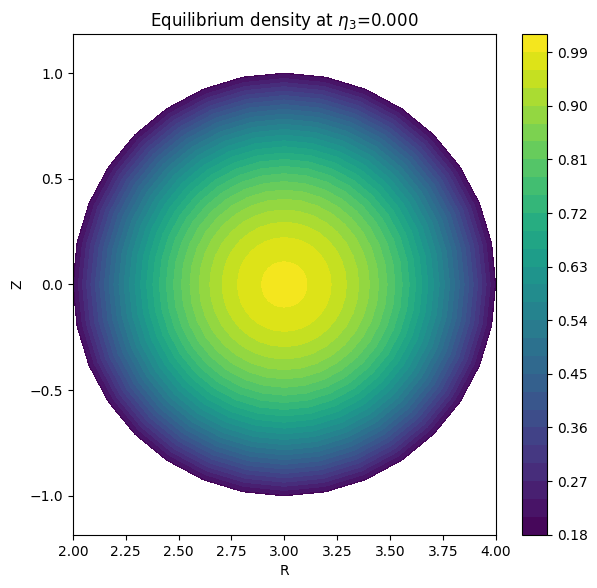

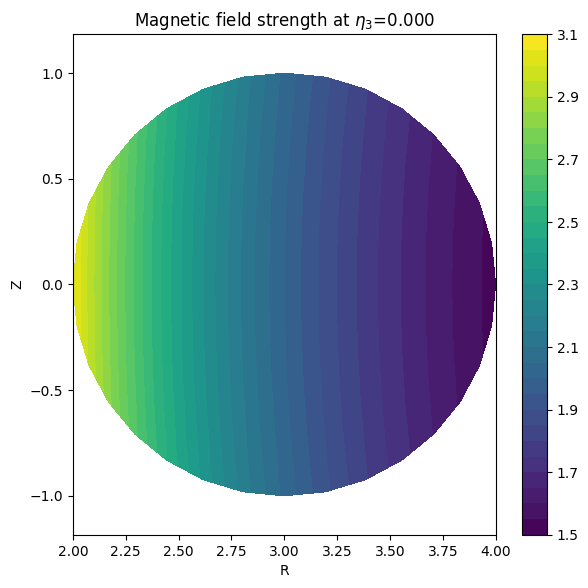

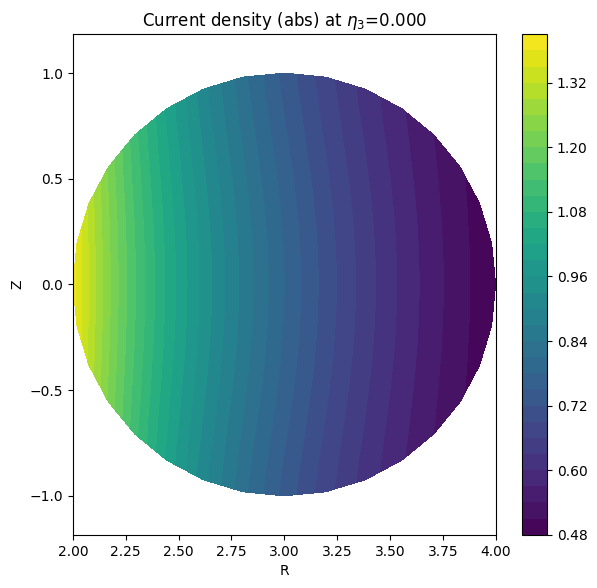

In [3]:
mhd_equil = equils.AdhocTorus()
mhd_equil.domain = domains.HollowTorus(a1=1e-8, tor_period=1)
mhd_equil.show()

## Example 3: EQDSK (Cartesian Equilibrium)

**EQDSK** is a `CartesianMHDequilibrium` that reads tokamak equilibria from EQDSK files (a standard format in fusion research). It constructs and stores the equilibrium in Cartesian coordinates.

We can assign any domain to this equilibrium, but typically we would use a `Tokamak` domain that matches the geometry of the EQDSK data.

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/fields_background/equils.py:1766: UserWarning: self.units =<struphy.physics.physics.Units object at 0x7f061a757400>, no rescaling performed in EQDSK output.
  warnings.warn(


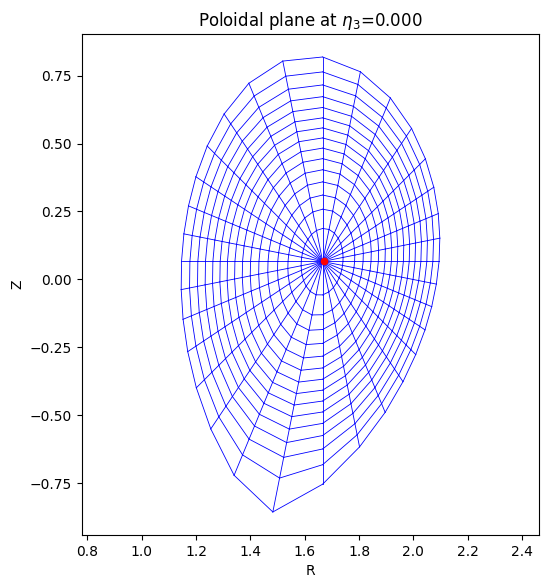

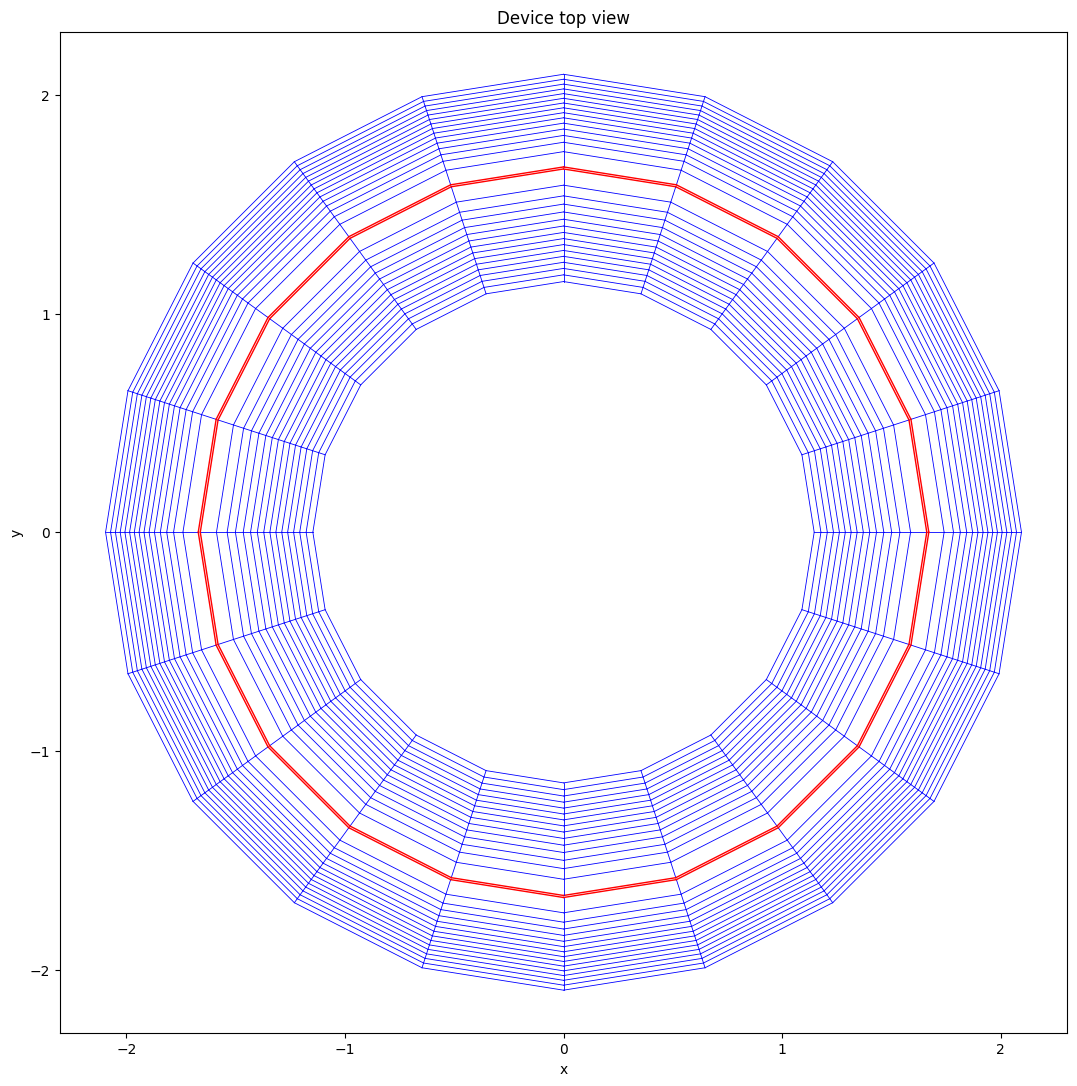

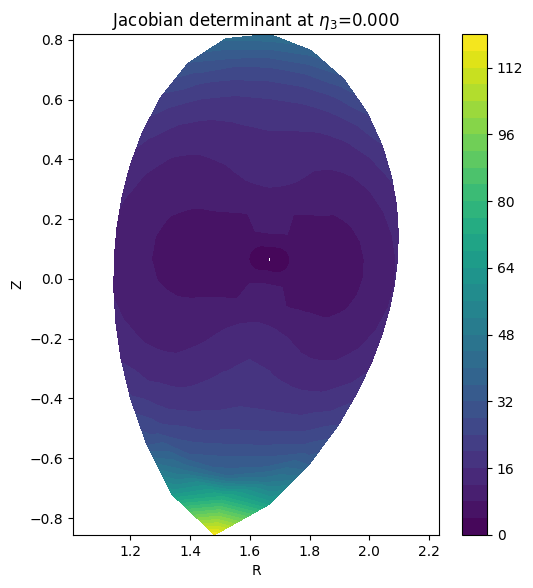

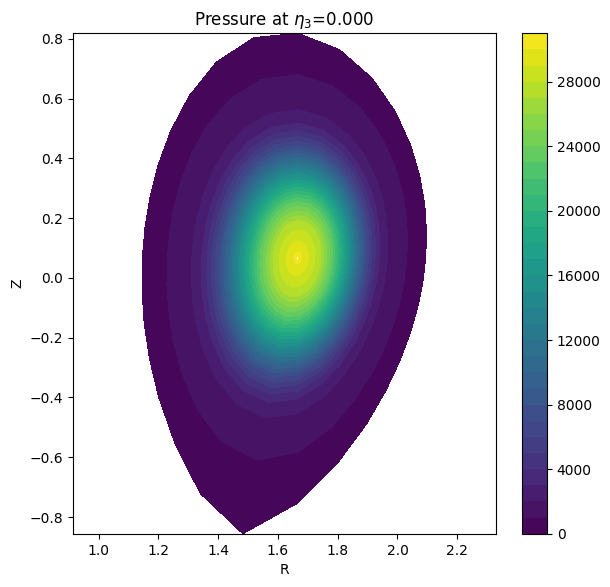

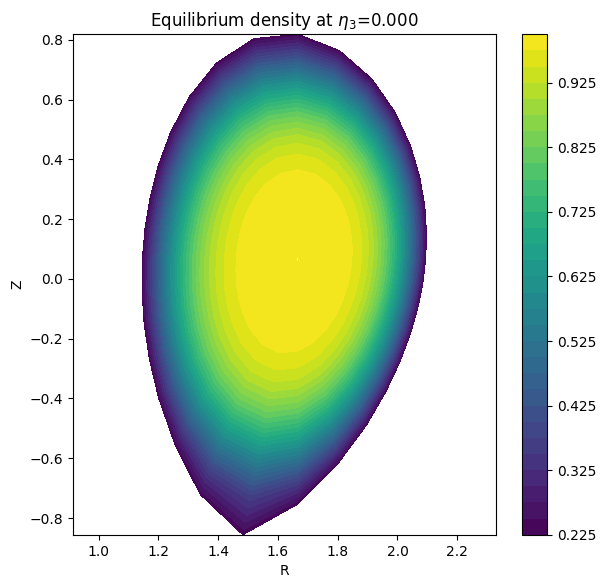

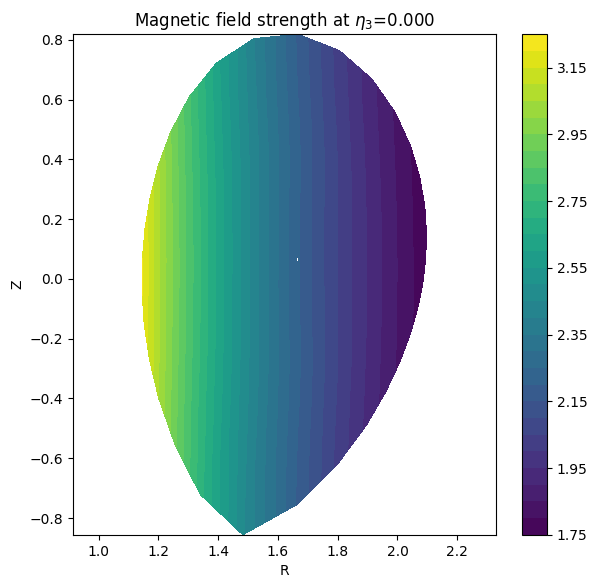

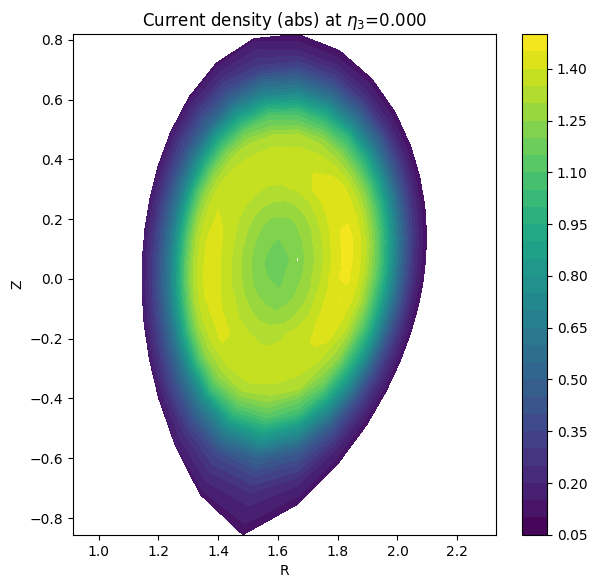

In [4]:
mhd_equil = equils.EQDSKequilibrium()
mhd_equil.domain = domains.Tokamak(equilibrium=mhd_equil)
mhd_equil.show()

## Example 4: GVEC (Logical Equilibrium)

**GVEC** (a stellarator equilibrium code) is another `LogicalMHDequilibrium`. Like EQDSK, it stores the equilibrium and geometry together. No separate domain assignment is needed.

**Notice:** We instantiate and plot directly. The geometry is already embedded in the equilibrium object.

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/fields_background/equils.py:2134: UserWarning: self.units =<struphy.physics.physics.Units object at 0x7f061b5c11e0>, no rescaling performed in GVEC output.
  warnings.warn(


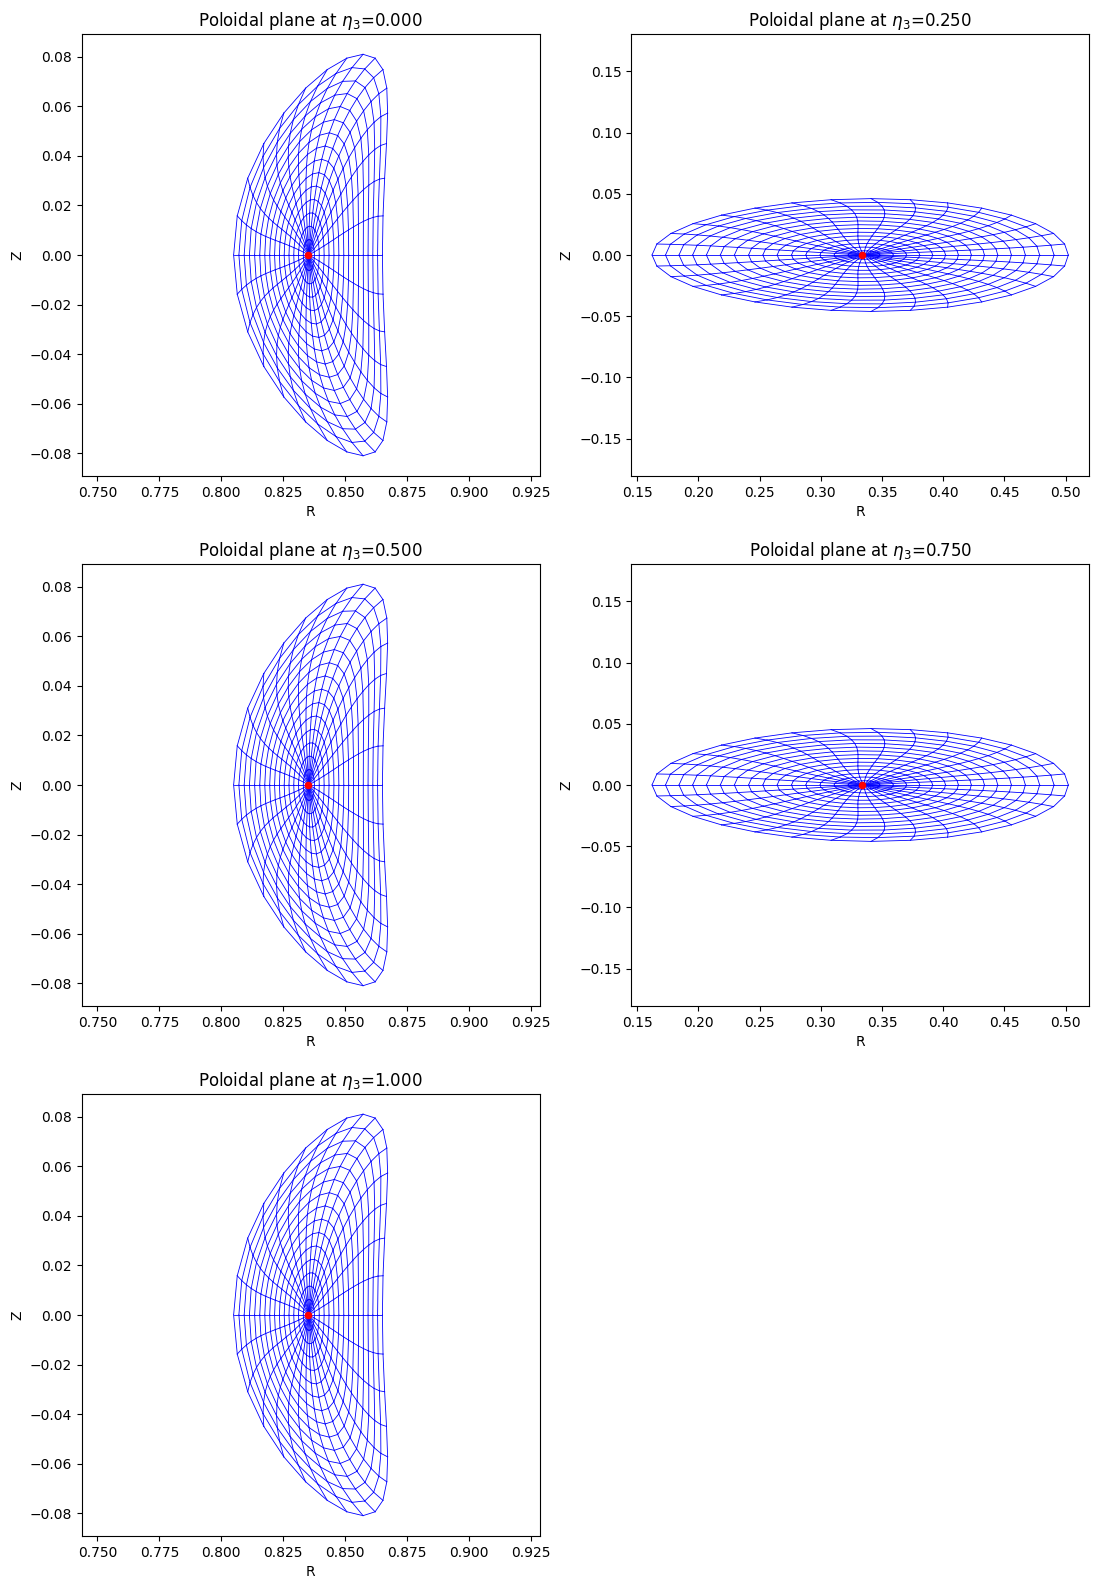

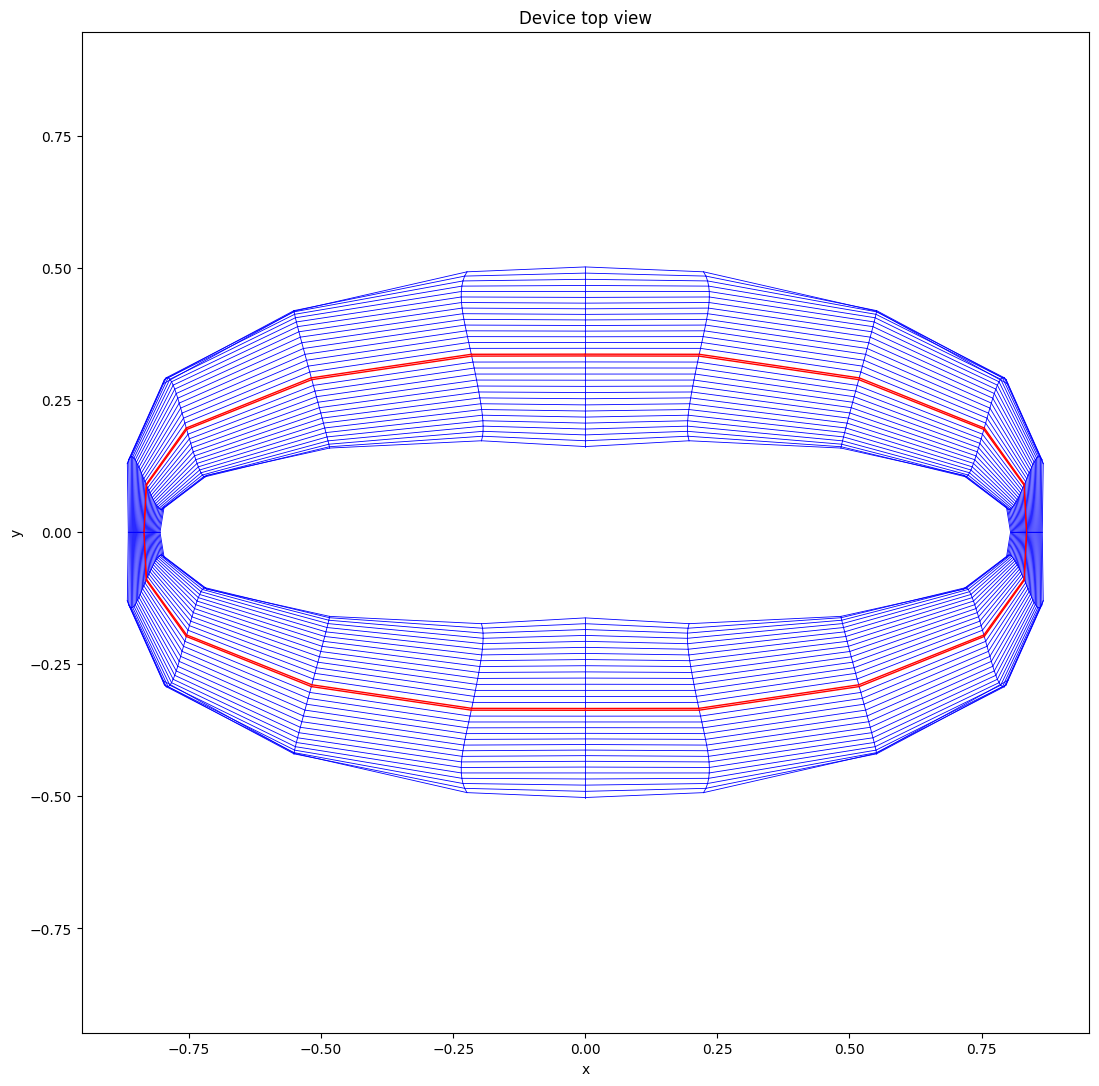

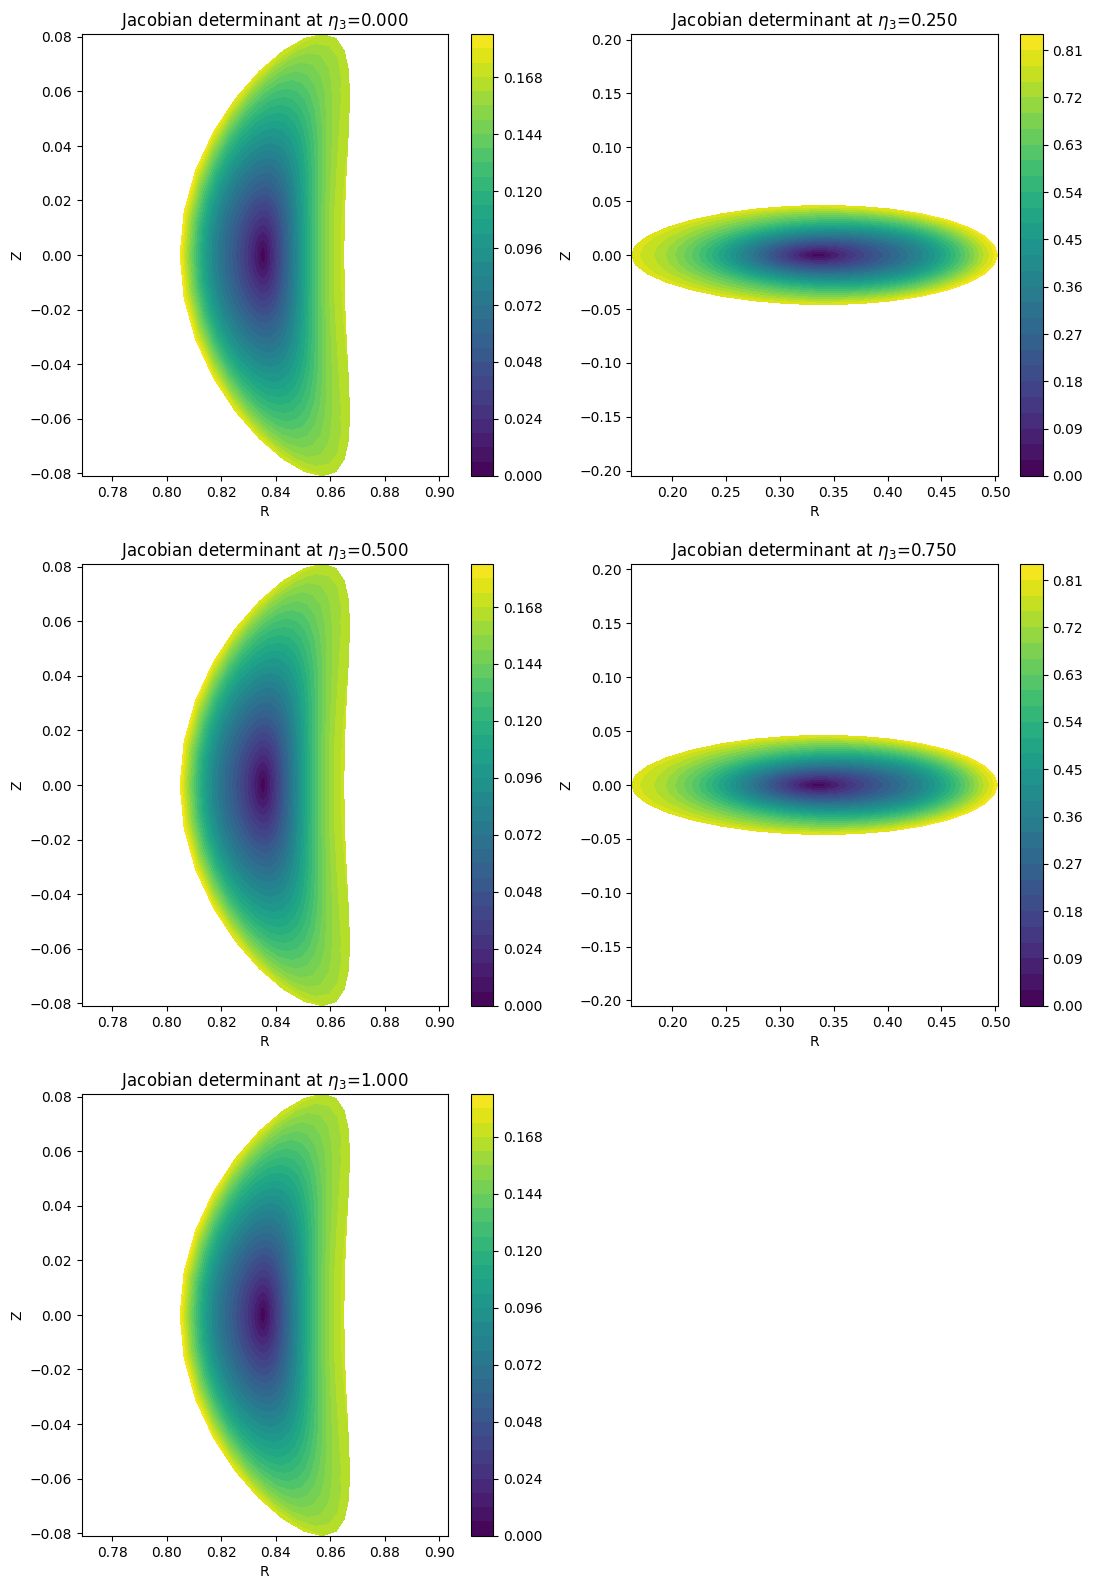

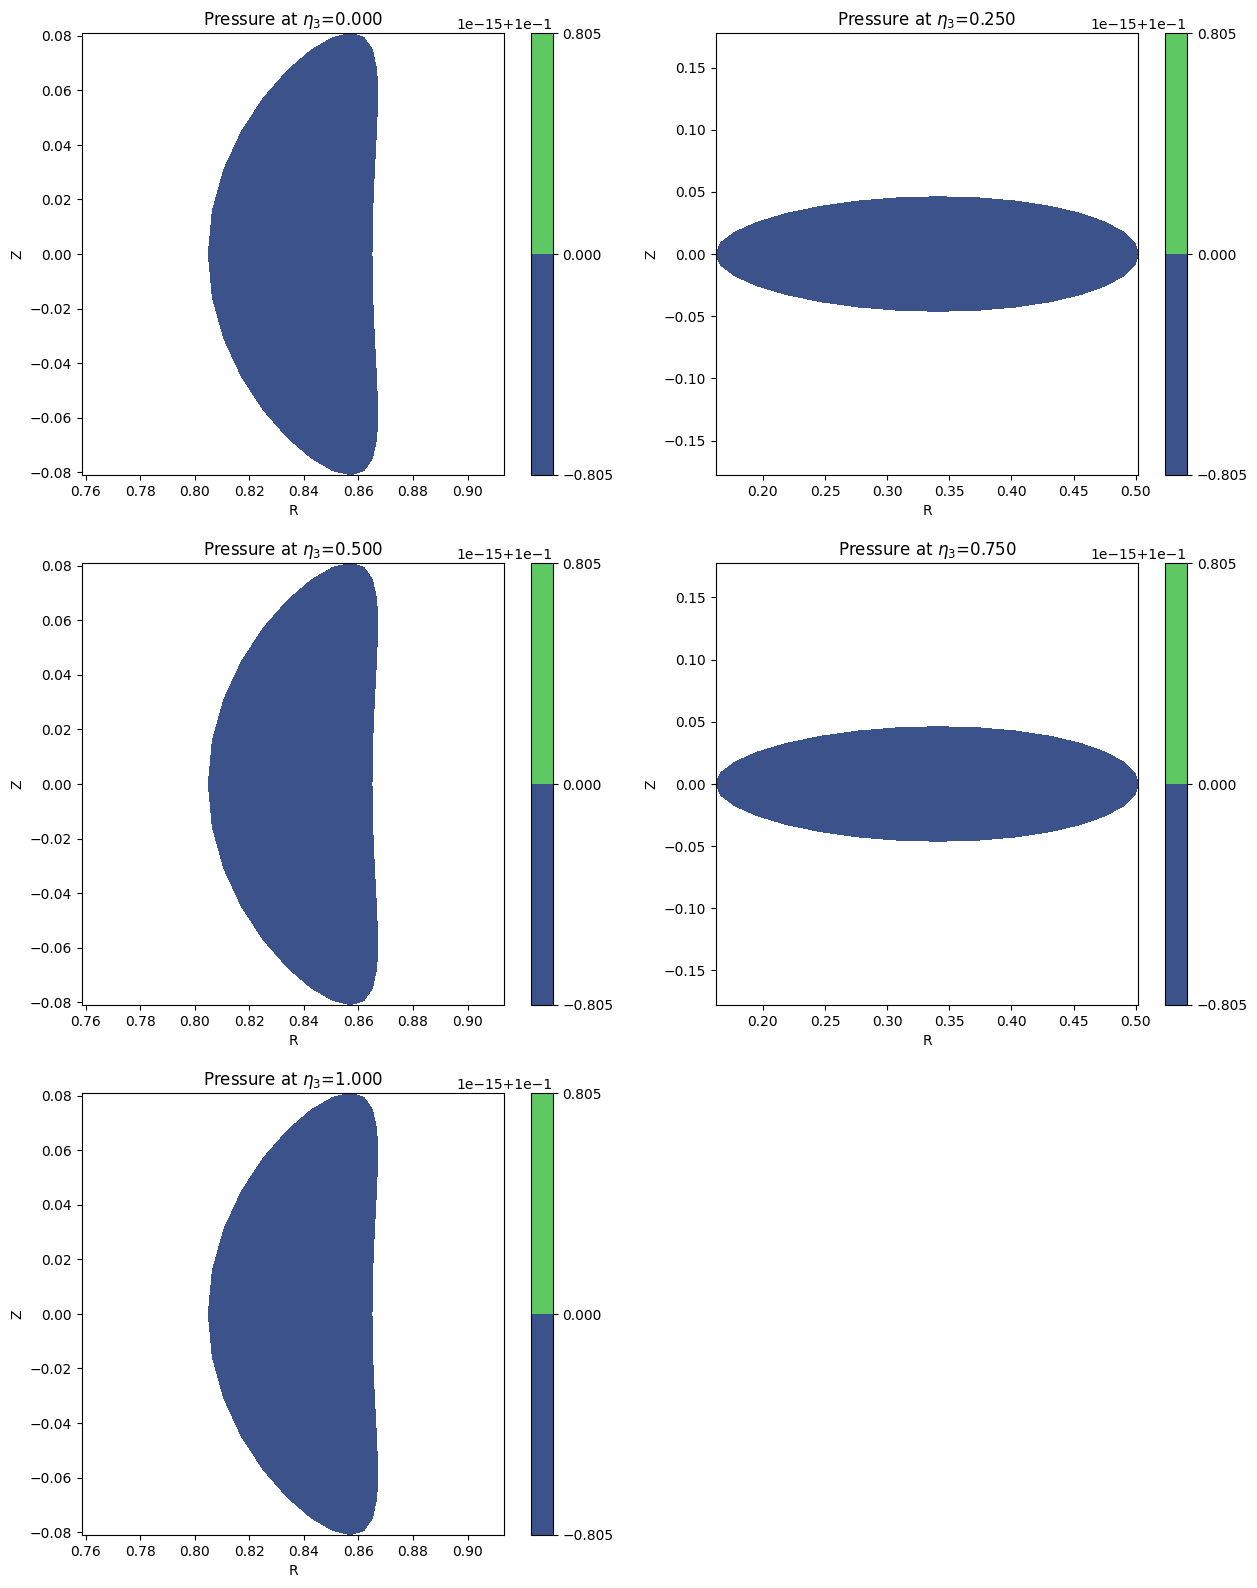

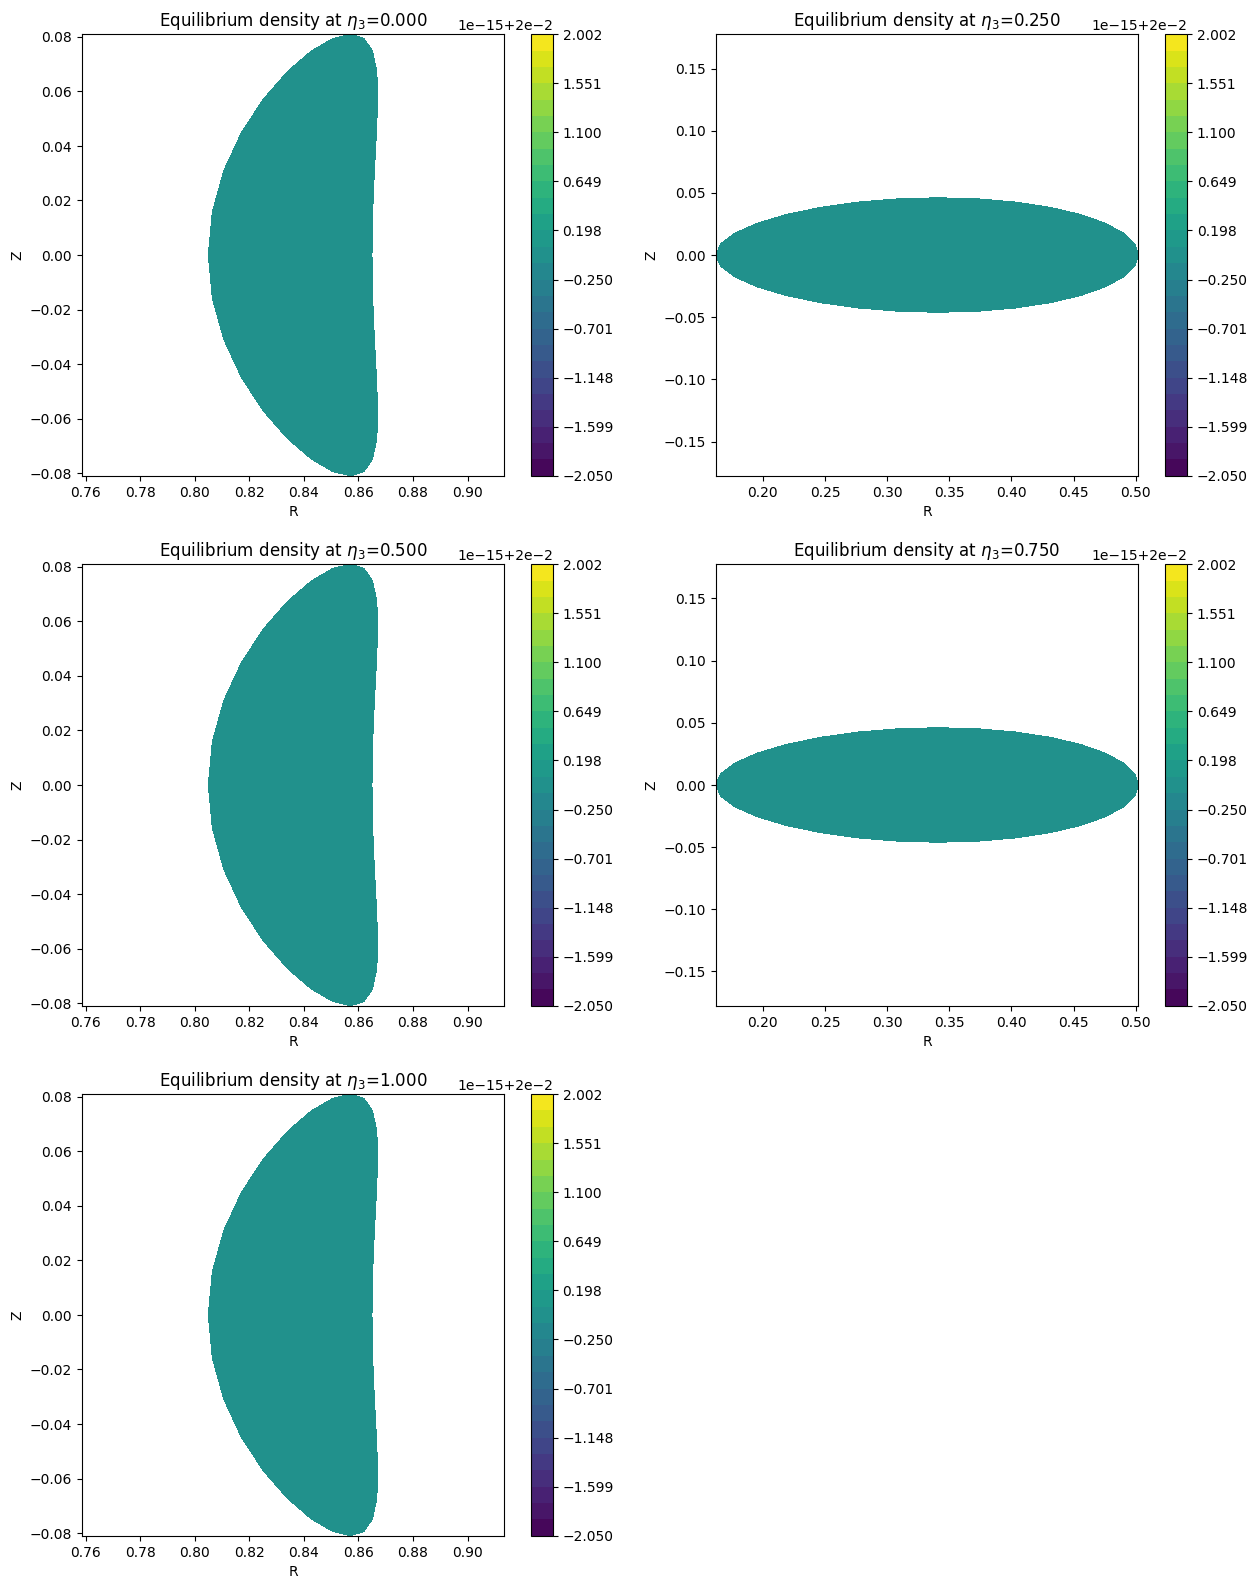

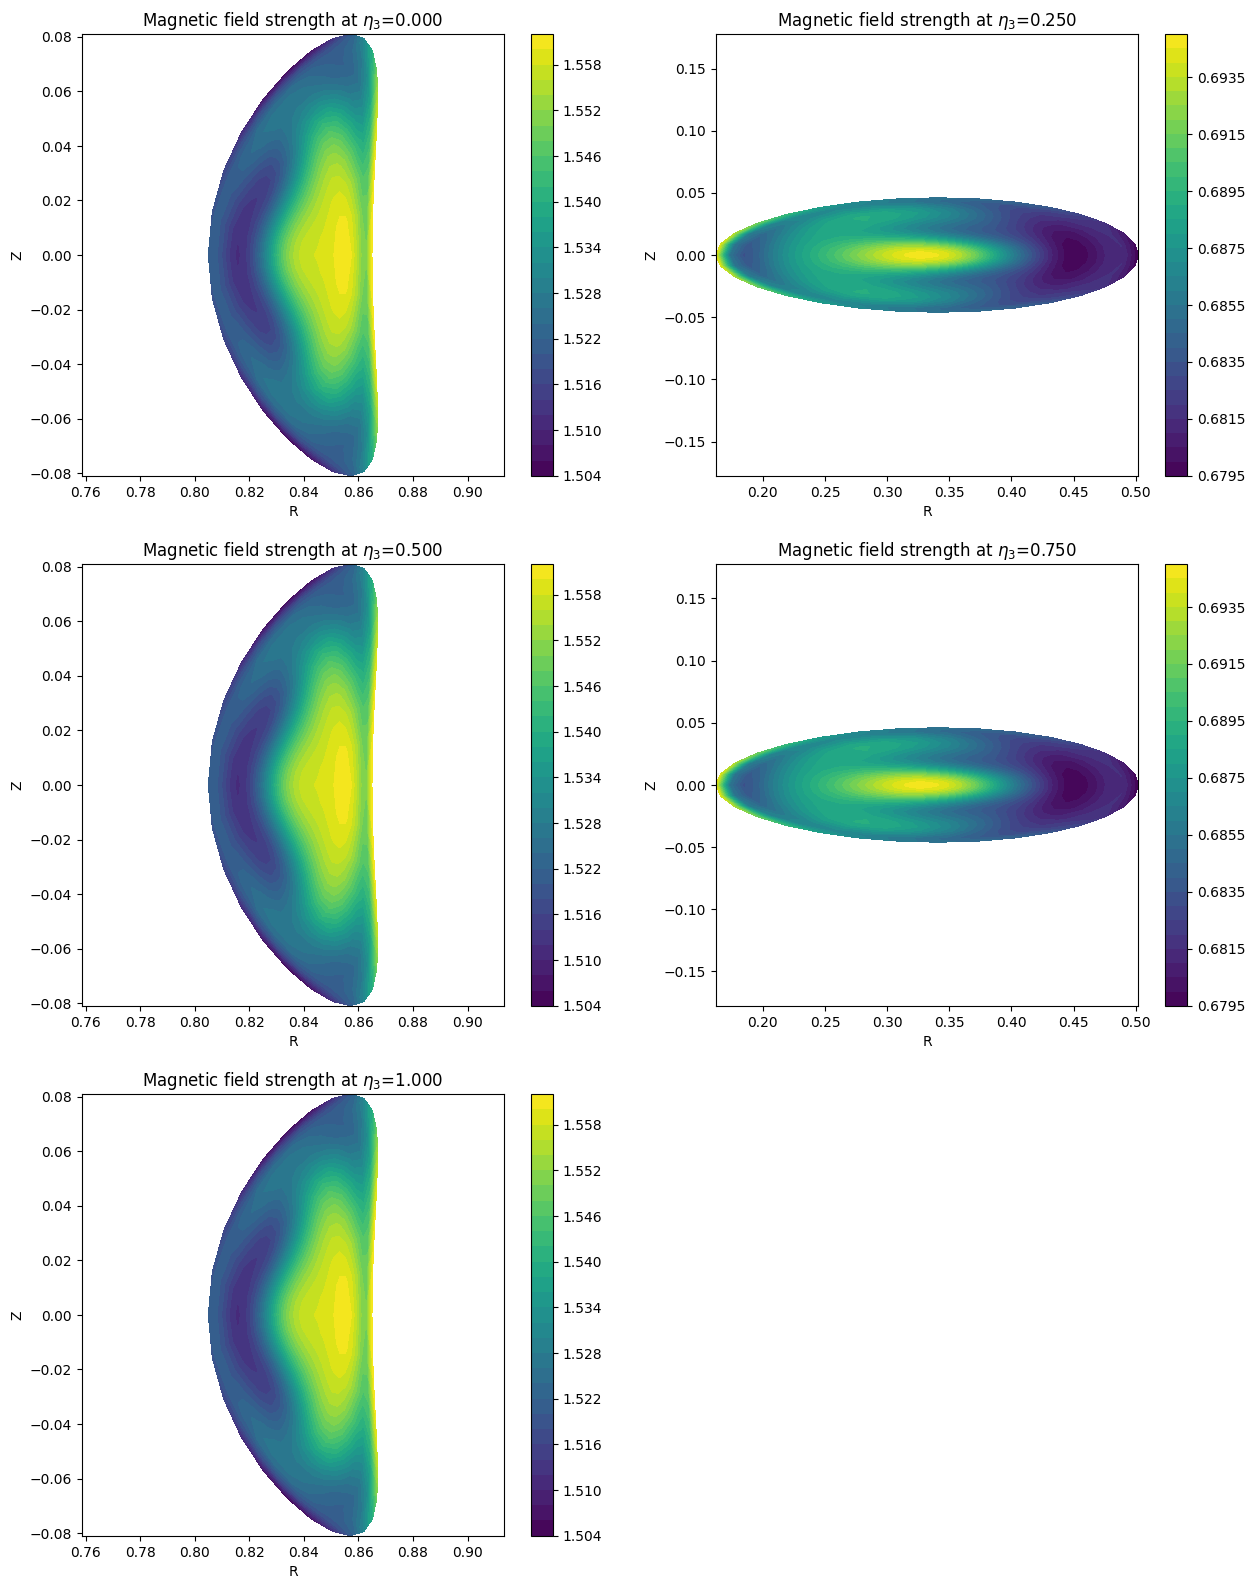

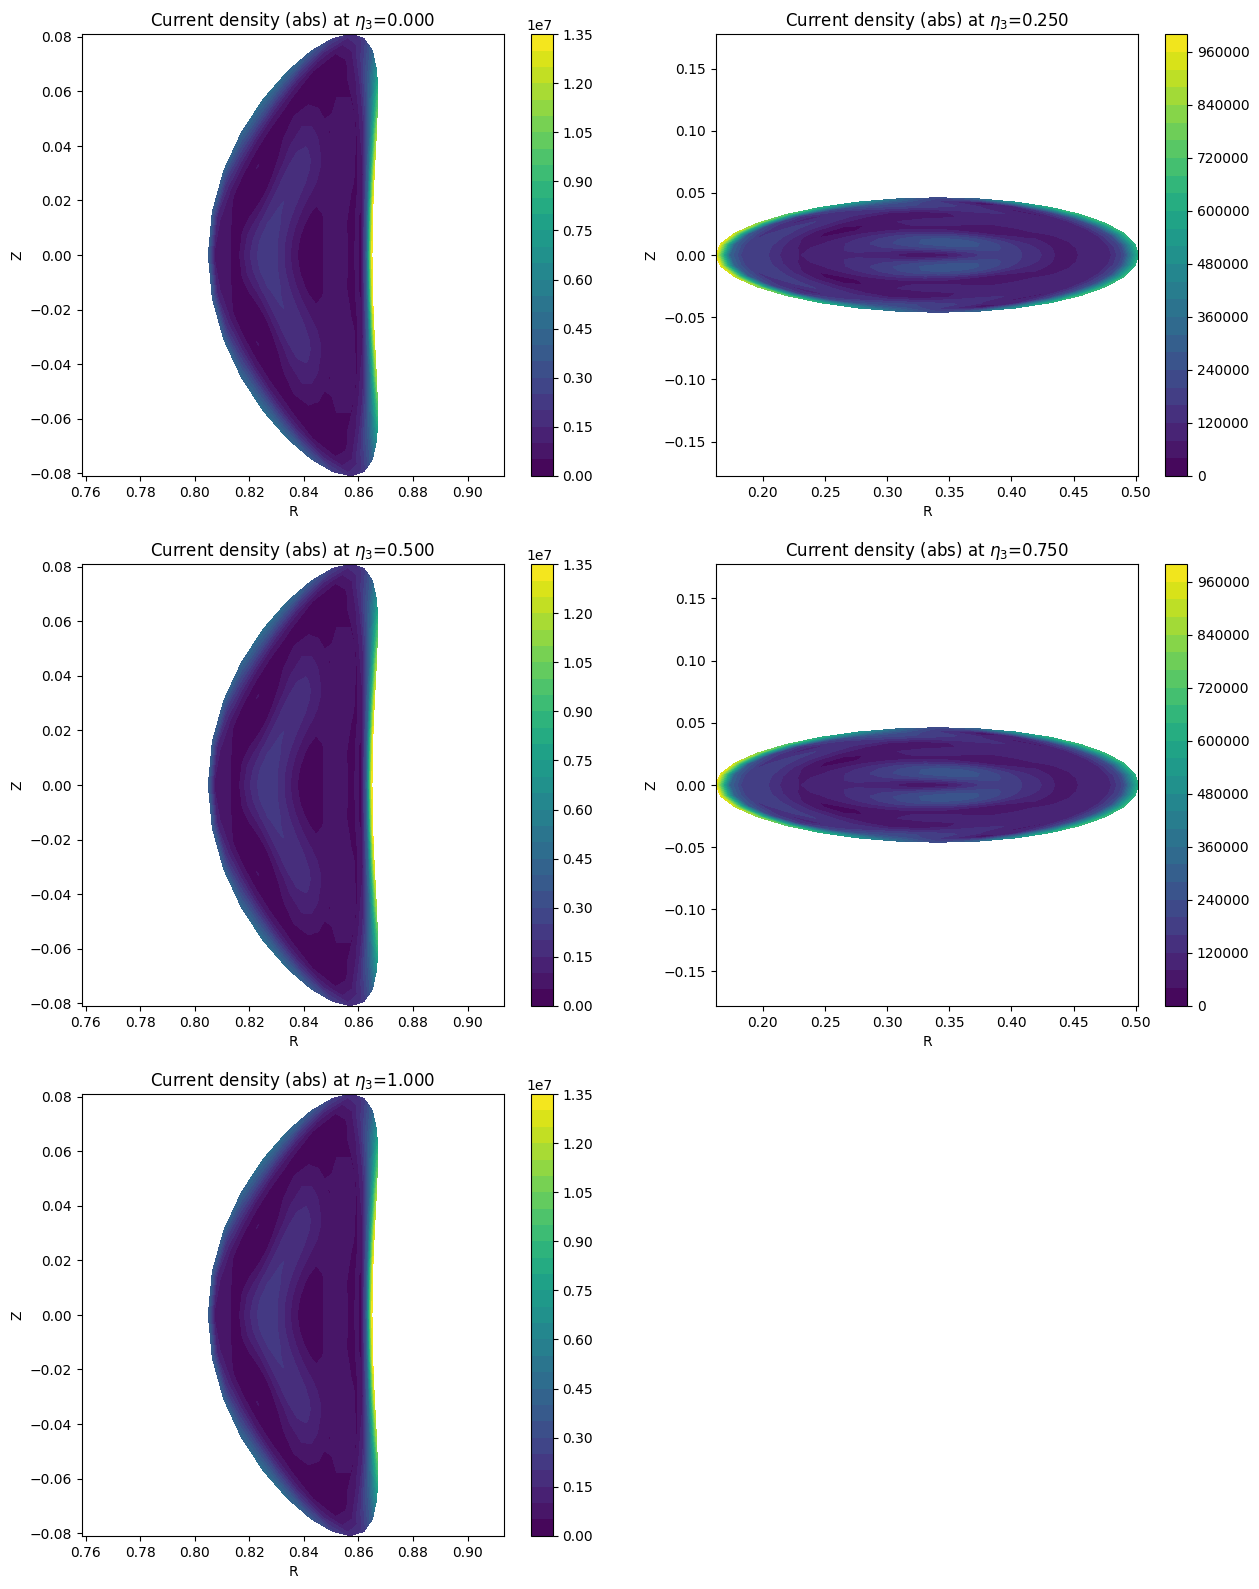

In [5]:
mhd_equil = equils.GVECequilibrium(use_nfp=False)
mhd_equil.show()

## Example 5: DESC (Logical Equilibrium)

**DESC** (Design of Equilibria with Stellarator Constraints) is a modern stellarator equilibrium optimizer. Like GVEC, it is a `LogicalMHDequilibrium` with built-in geometry.

**About the `%%capture` cell above:** DESC initialization can produce verbose output. The `%%capture` magic silences it so the notebook remains clean. The `mhd_equil` object is still created and available for use.

In [6]:
%%capture
mhd_equil = equils.DESCequilibrium(use_nfp=False)

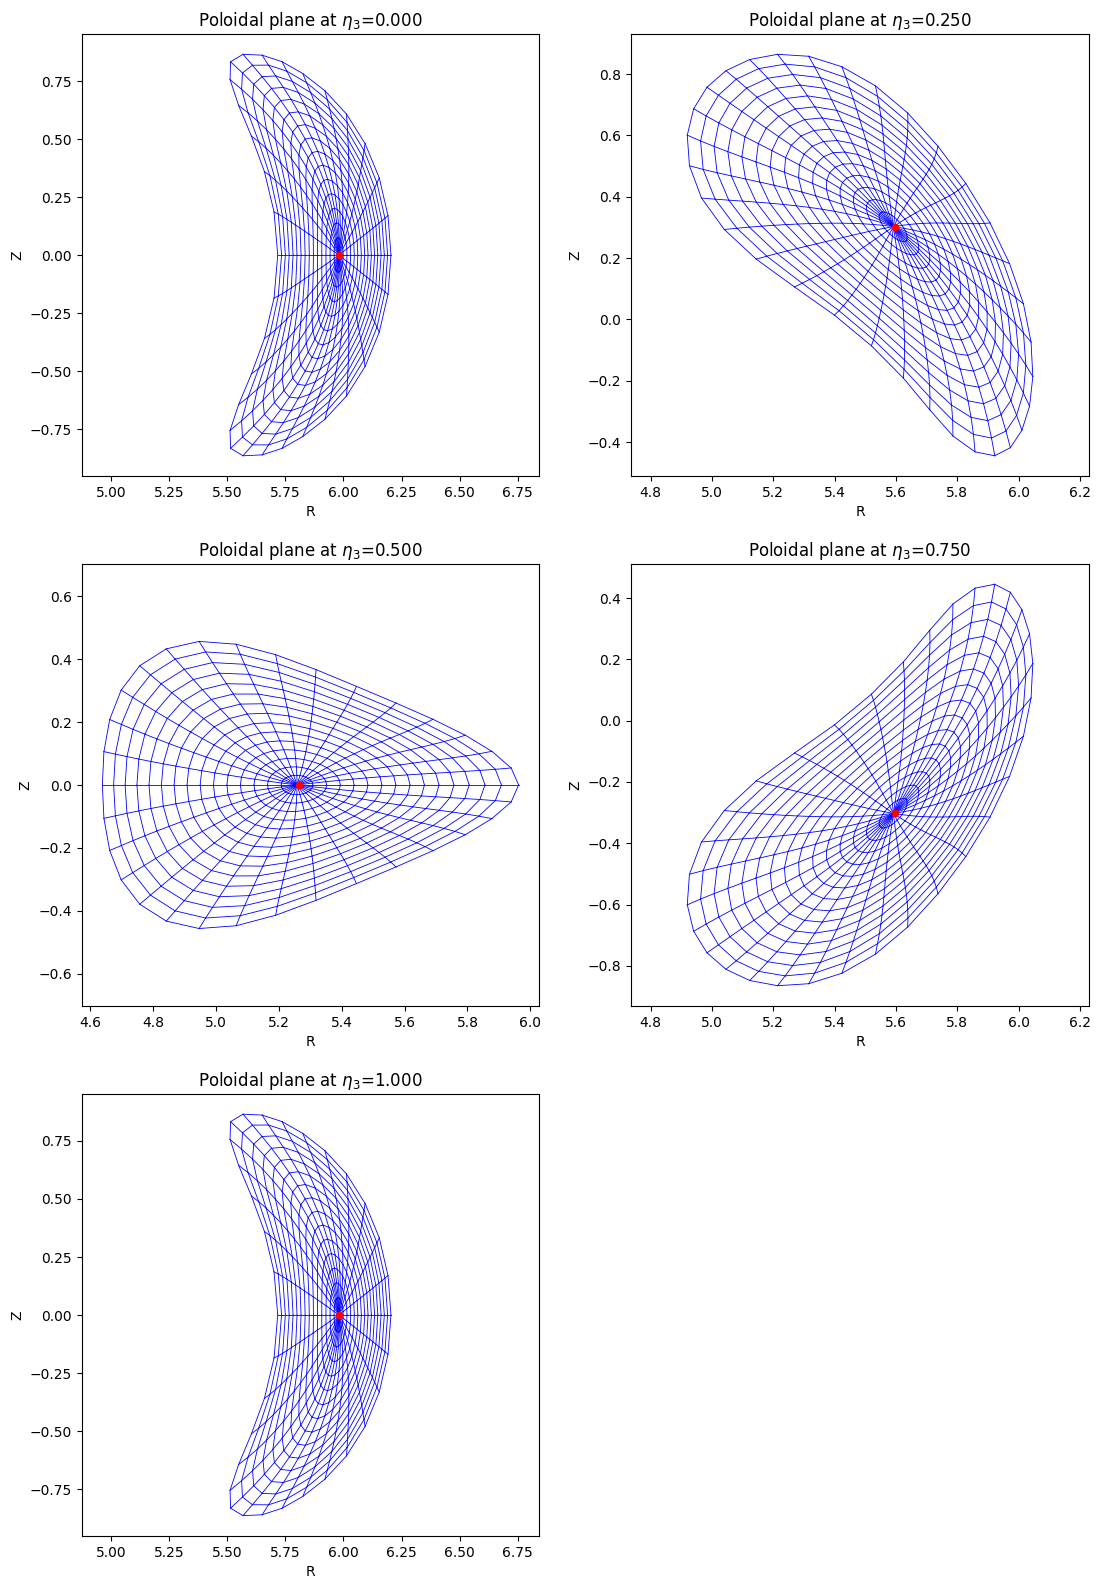

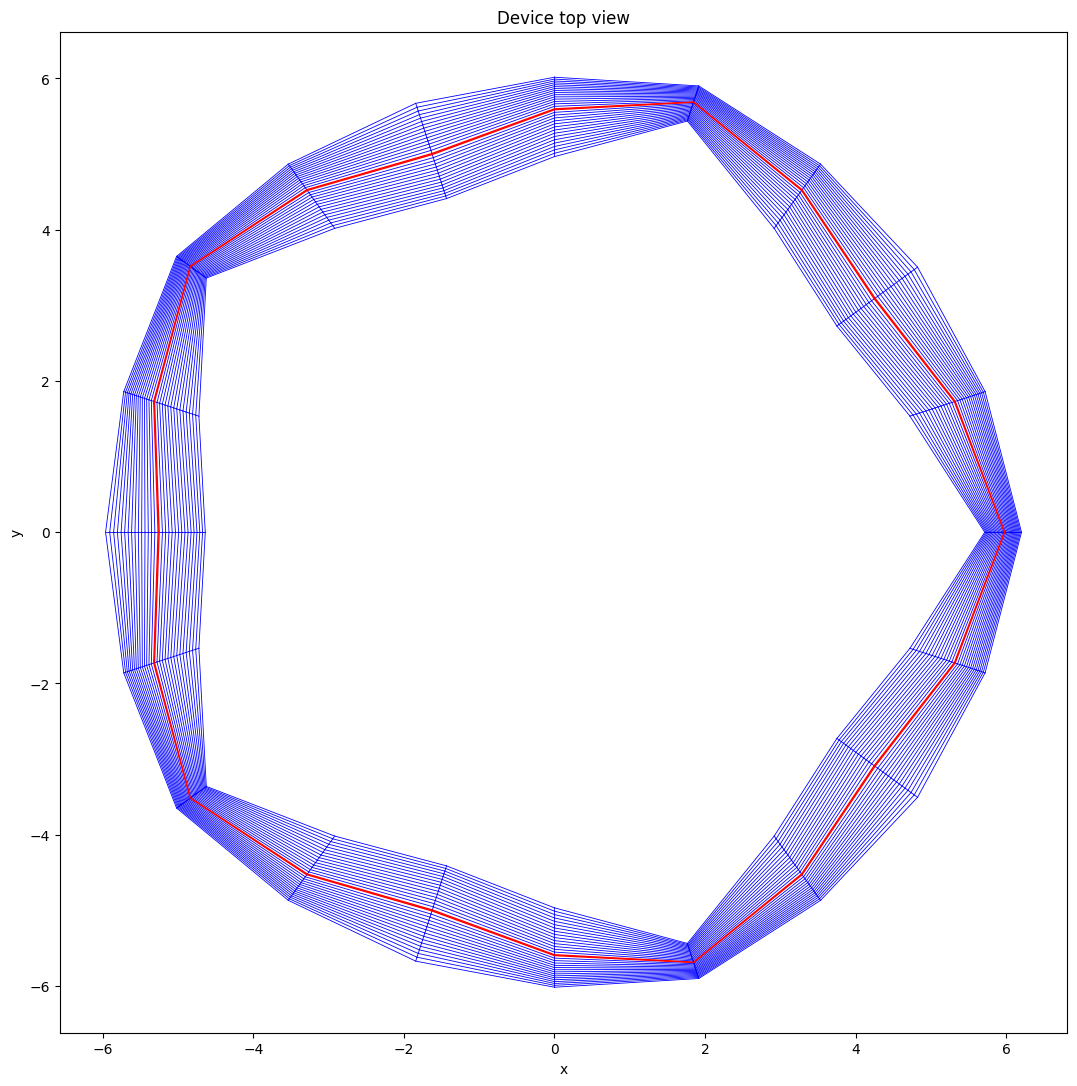

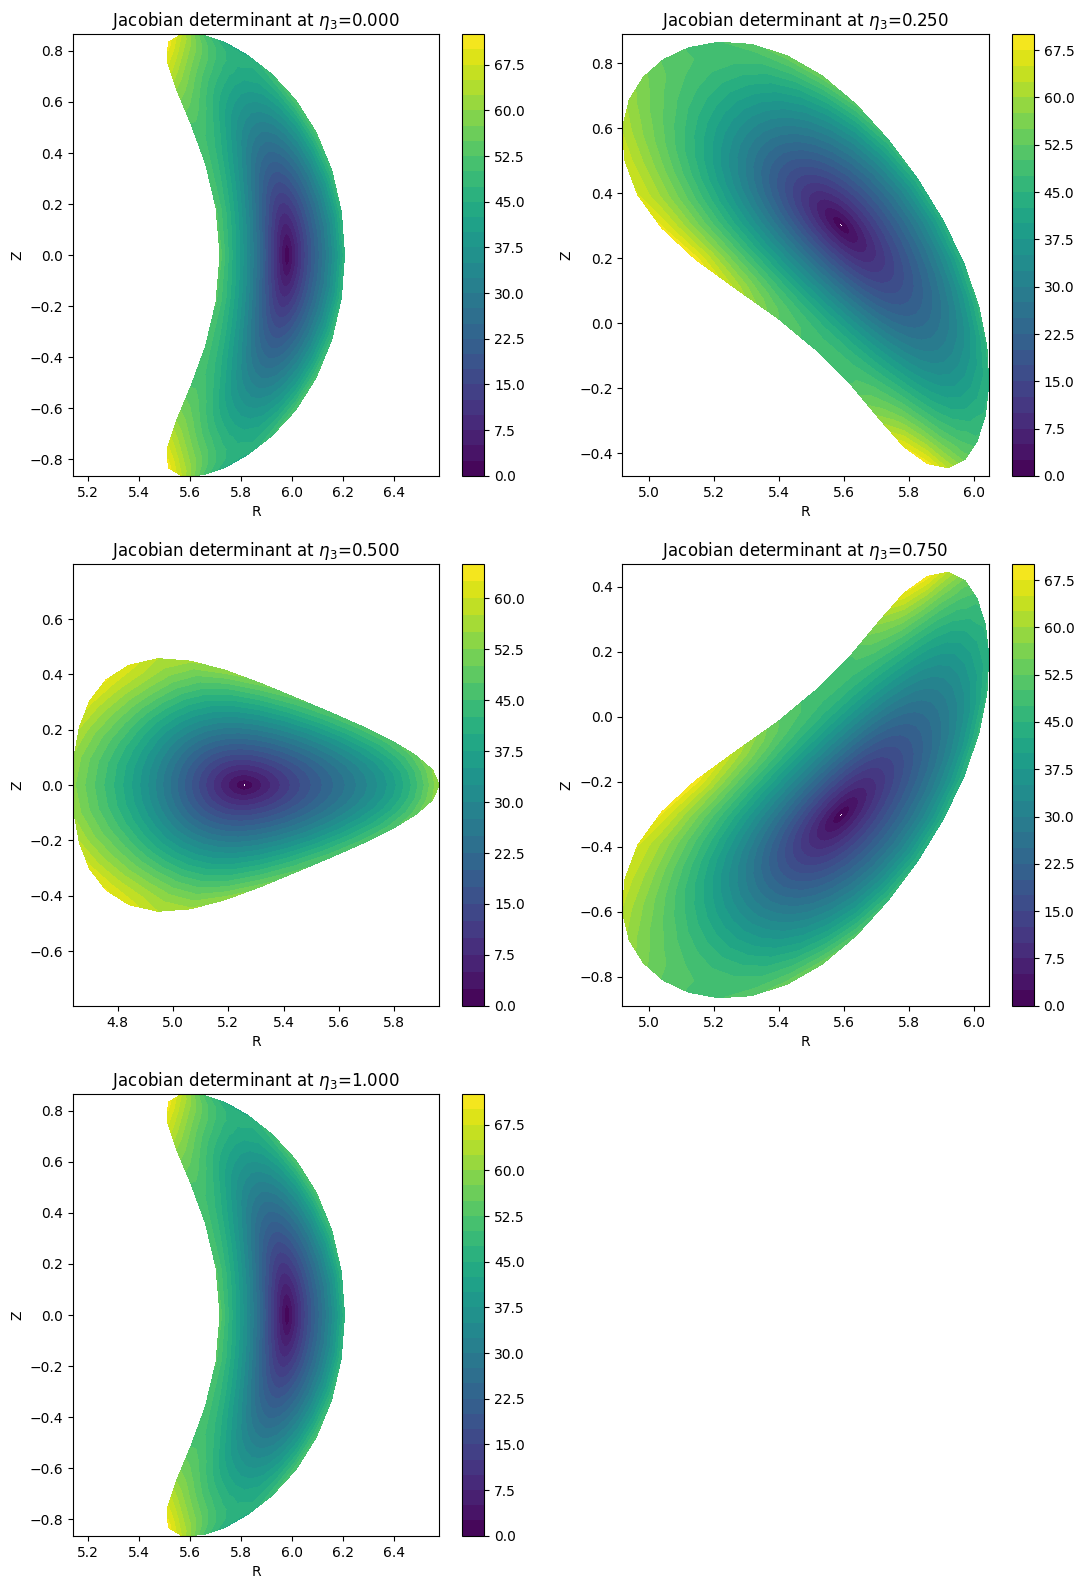

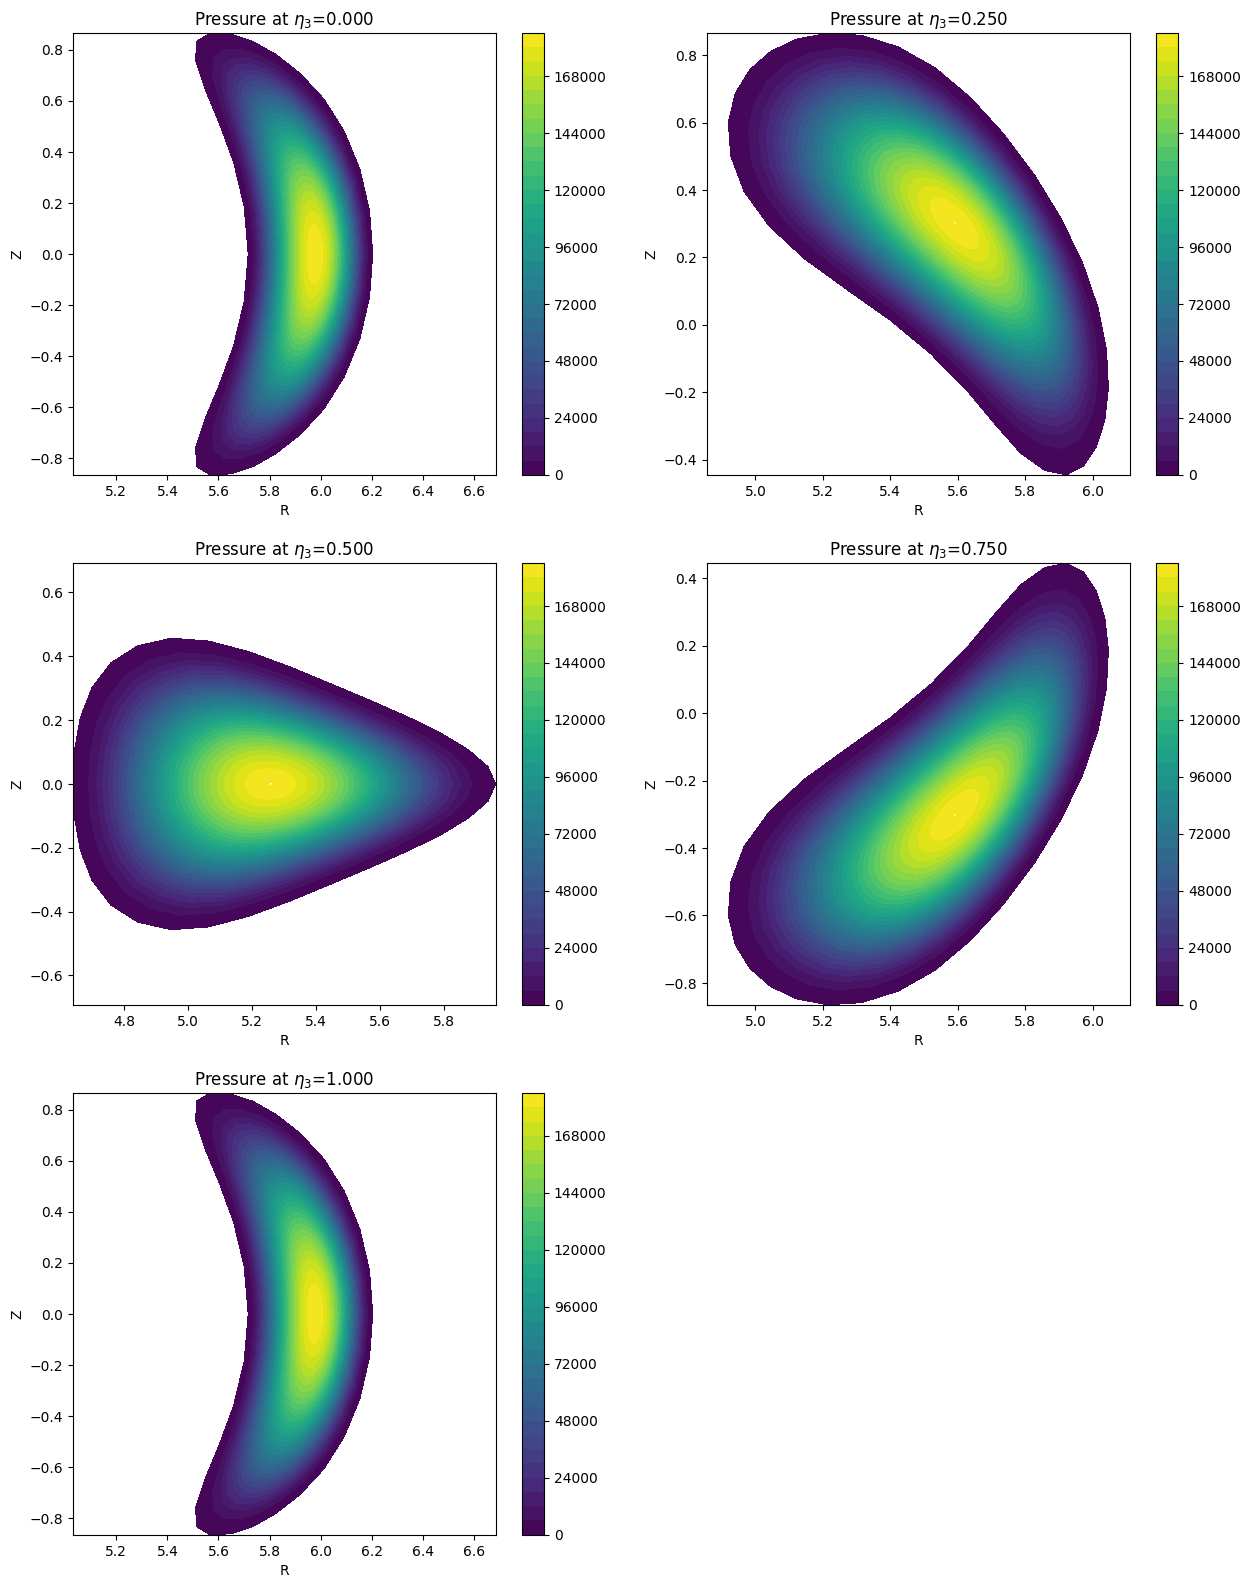

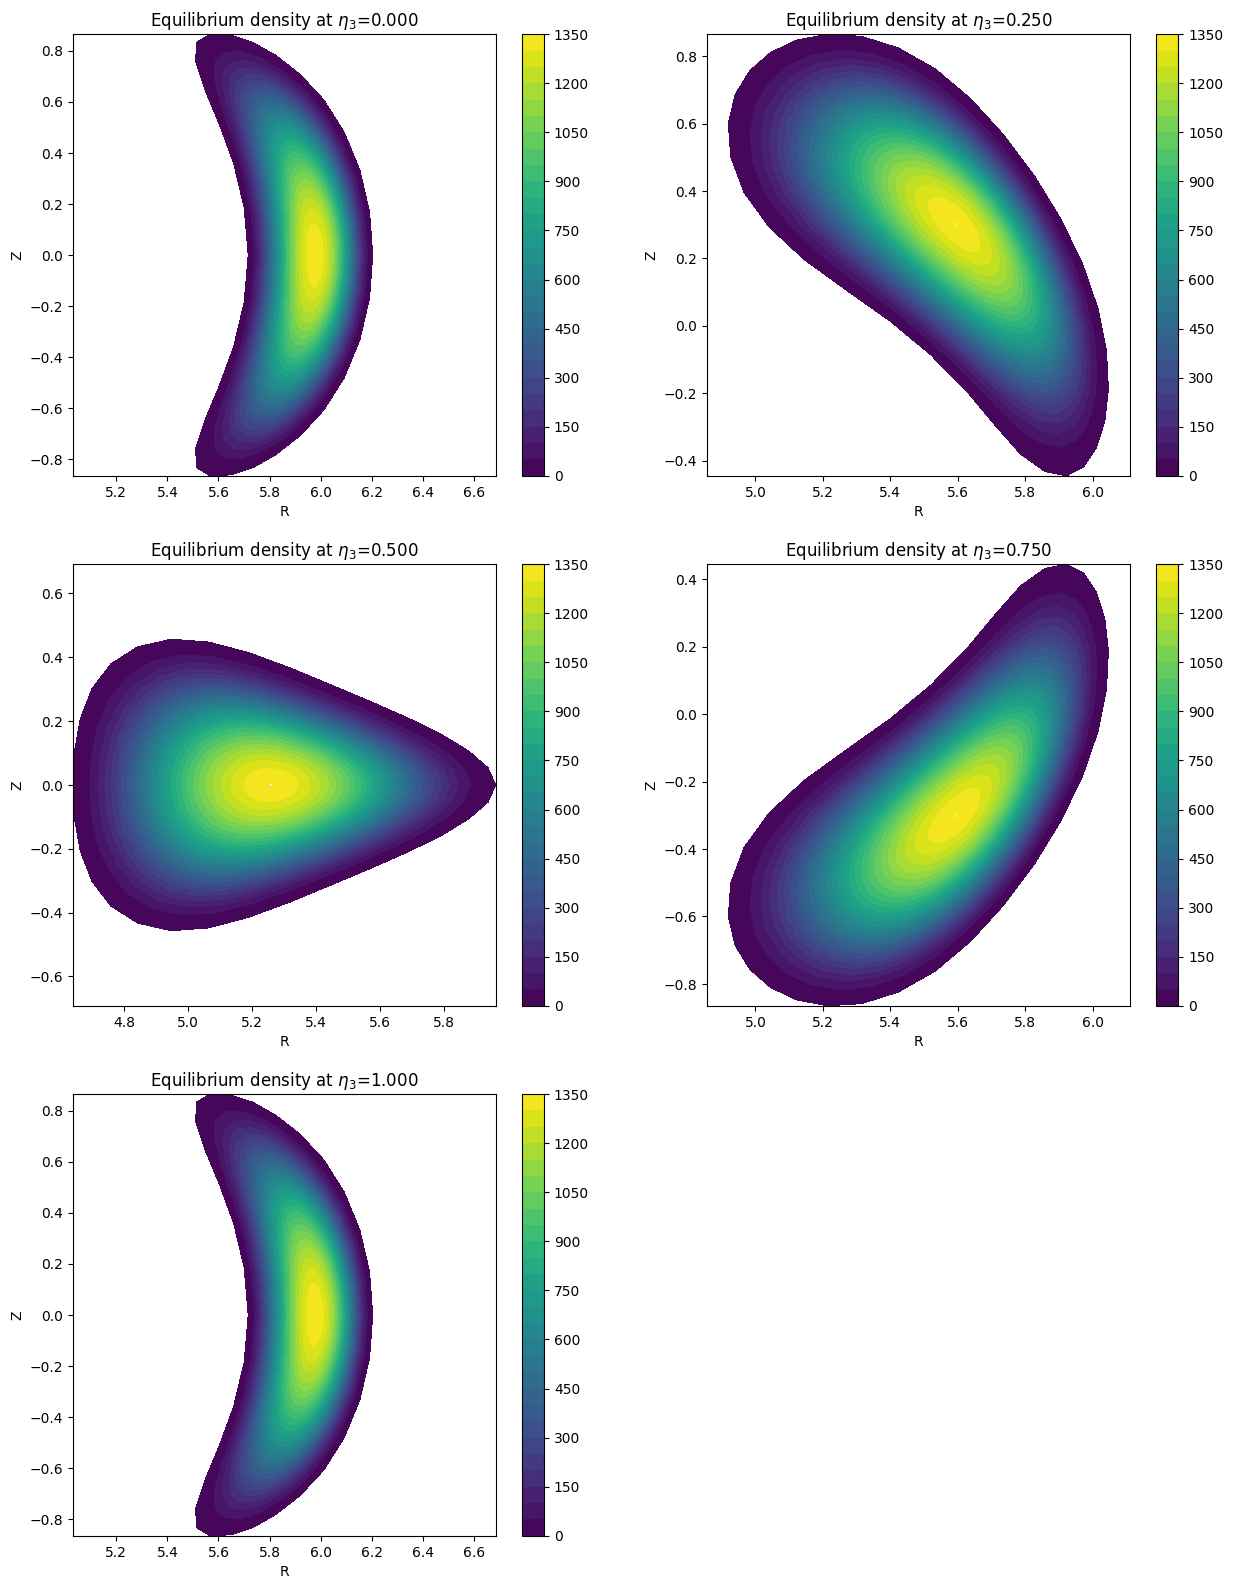

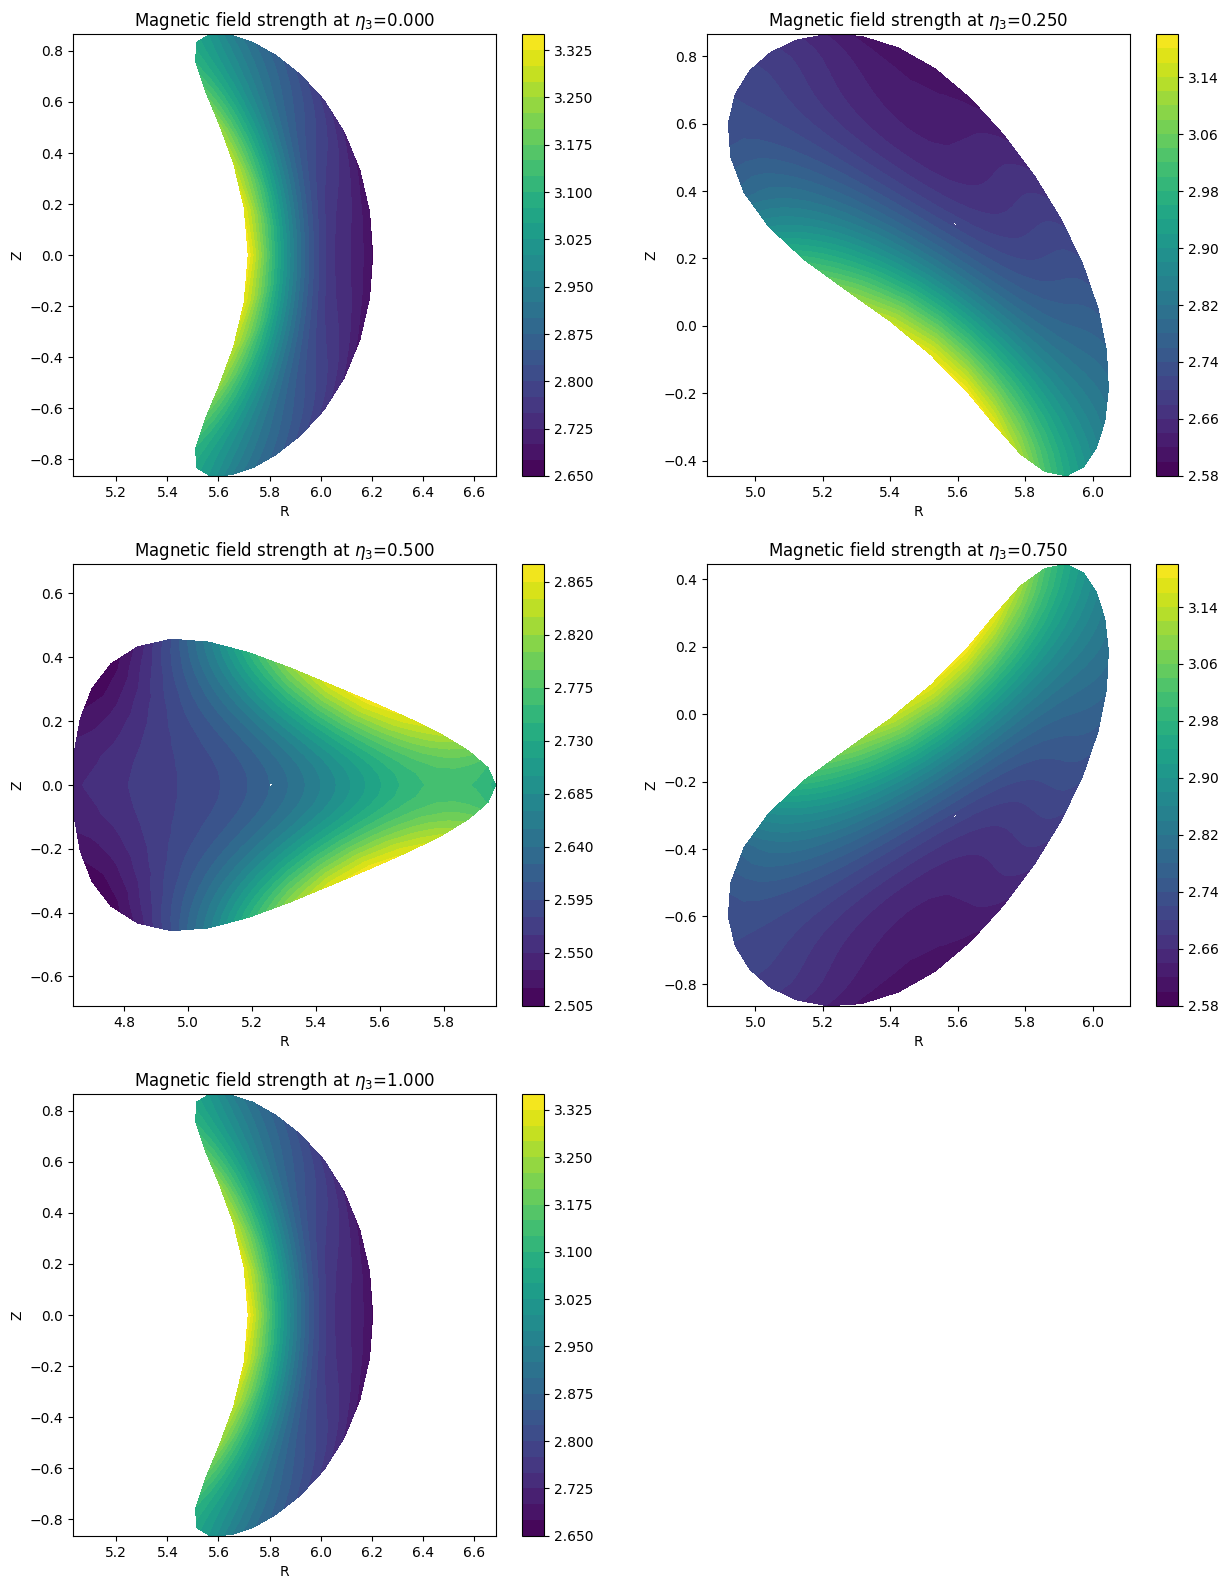

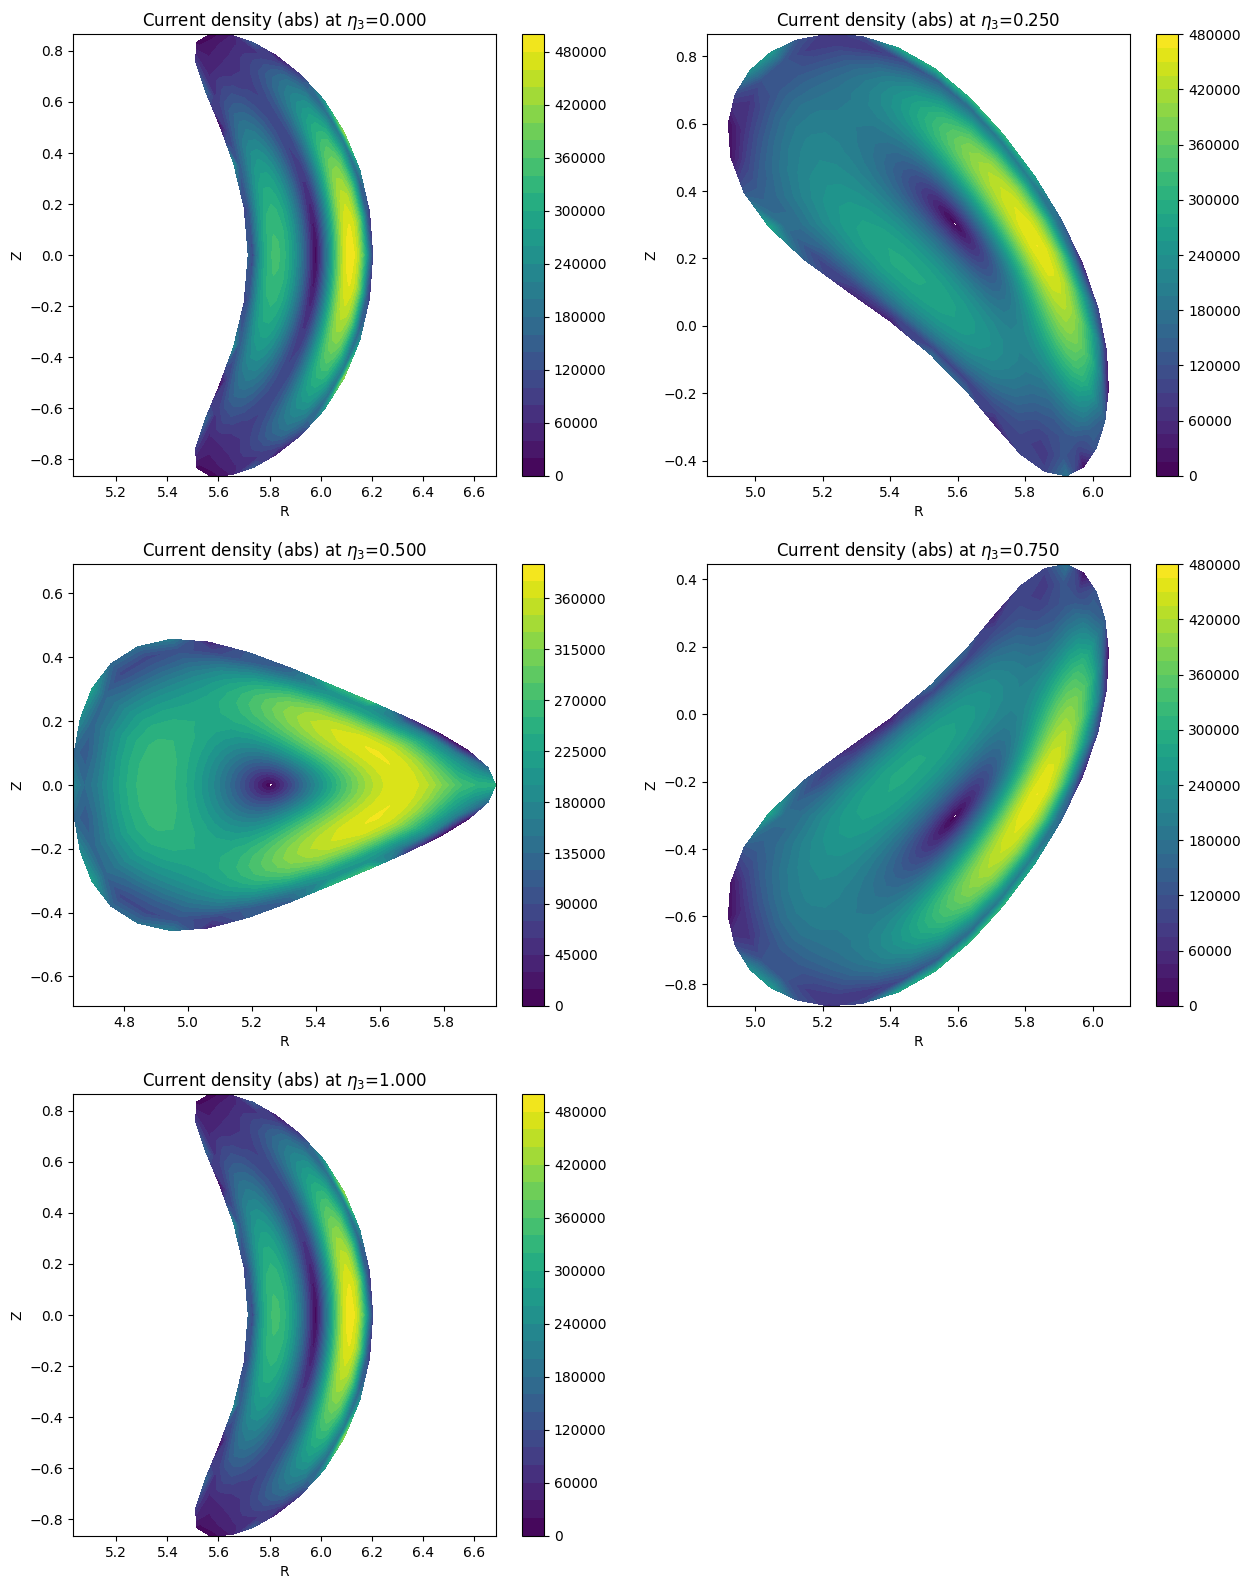

In [7]:
mhd_equil.show()